# OPAN-6603: Saxa 4 Project 3

## Step 0: Import Packages and Data
---
---

In [1]:
## Setup

!pip install --upgrade gspread # Install gspread if it's not already updated

In [2]:
from google.colab import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.manifold import TSNE

from matplotlib.colors import ListedColormap

from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [4]:
RANDOM_SEED = 315
np.random.seed(RANDOM_SEED)

In [5]:
uploaded = files.upload()
df = pd.read_excel('Travel_Review.xlsx')

Saving Travel_Review.xlsx to Travel_Review.xlsx


## Step 1: Pre-Processing
---
---

In [6]:
print(f"Shape: {df.shape}")
print(df.info())
print(df.head())

Shape: (5455, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5455 entries, 0 to 5454
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                5455 non-null   object 
 1   Churches              5455 non-null   float64
 2   Resorts               5455 non-null   float64
 3   Beaches               5455 non-null   float64
 4   Parks                 5455 non-null   float64
 5   Theatres              5455 non-null   float64
 6   Museums               5455 non-null   float64
 7   Malls                 5455 non-null   float64
 8   Zoo                   5455 non-null   float64
 9   Restaurants           5455 non-null   float64
 10  Pubs_Bars             5455 non-null   float64
 11  LocalServices         5455 non-null   float64
 12  Burger_PizzaShops     5455 non-null   float64
 13  Hotels_OtherLodgings  5455 non-null   float64
 14  JuiceBars             5455 non-null   float64
 15  Art

In [7]:
df['Gardens'] = df['Gardens'].fillna(0)

In [8]:
df.isna().sum()

,0
UserID,0
Churches,0
Resorts,0
Beaches,0
Parks,0
Theatres,0
Museums,0
Malls,0
Zoo,0
Restaurants,0


In [9]:
users_cols = ["UserID"]
reviews_cols = [
    "Churches", "Resorts", "Beaches", "Parks", "Theatres", "Museums",
    "Malls", "Zoo", "Restaurants", "Pubs_Bars", "LocalServices",
    "Burger_PizzaShops", "Hotels_OtherLodgings", "JuiceBars",
    "ArtGalleries", "DanceClubs", "Swimming Pools", "Gyms", "Bakeries",
    "BeautySpas", "Cafes", "ViewPoints", "Monuments", "Gardens"
]
df_users = df[users_cols].copy()
df_reviews = df[reviews_cols].copy()

print("Clustering features:", reviews_cols)
print("Context variables (not used in clustering):", users_cols)

Clustering features: ['Churches', 'Resorts', 'Beaches', 'Parks', 'Theatres', 'Museums', 'Malls', 'Zoo', 'Restaurants', 'Pubs_Bars', 'LocalServices', 'Burger_PizzaShops', 'Hotels_OtherLodgings', 'JuiceBars', 'ArtGalleries', 'DanceClubs', 'Swimming Pools', 'Gyms', 'Bakeries', 'BeautySpas', 'Cafes', 'ViewPoints', 'Monuments', 'Gardens']
Context variables (not used in clustering): ['UserID']


In [10]:
# --- Remove low-engagement users (too many zeros) ---
X = df[reviews_cols].copy()
zero_frac = (X == 0).mean(axis=1)

MAX_ZERO_FRAC = 0.25
keep_mask = zero_frac <= MAX_ZERO_FRAC

df = df.loc[keep_mask].reset_index(drop=True)
X = df[reviews_cols].copy()

data = df.drop('UserID', axis=1)
categories = data.columns.to_list()
users = df['UserID'].copy()

print("Original users:", 5456)
print("Kept users:", df.shape[0])
print("Dropped users:", 5456 - df.shape[0])
print("Mean zero fraction (kept):", round((X == 0).mean(axis=1).mean(), 3))
print("Mean zero fraction (dropped):", round((df_reviews.loc[~keep_mask] == 0).mean(axis=1).mean(), 3))

Original users: 5456
Kept users: 5358
Dropped users: 98
Mean zero fraction (kept): 0.036
Mean zero fraction (dropped): 0.306


## Step 2: Train/Test Split
---
---

## Step 3: Exploratory Data Analysis
---
---

In [11]:
n_pcs = 8

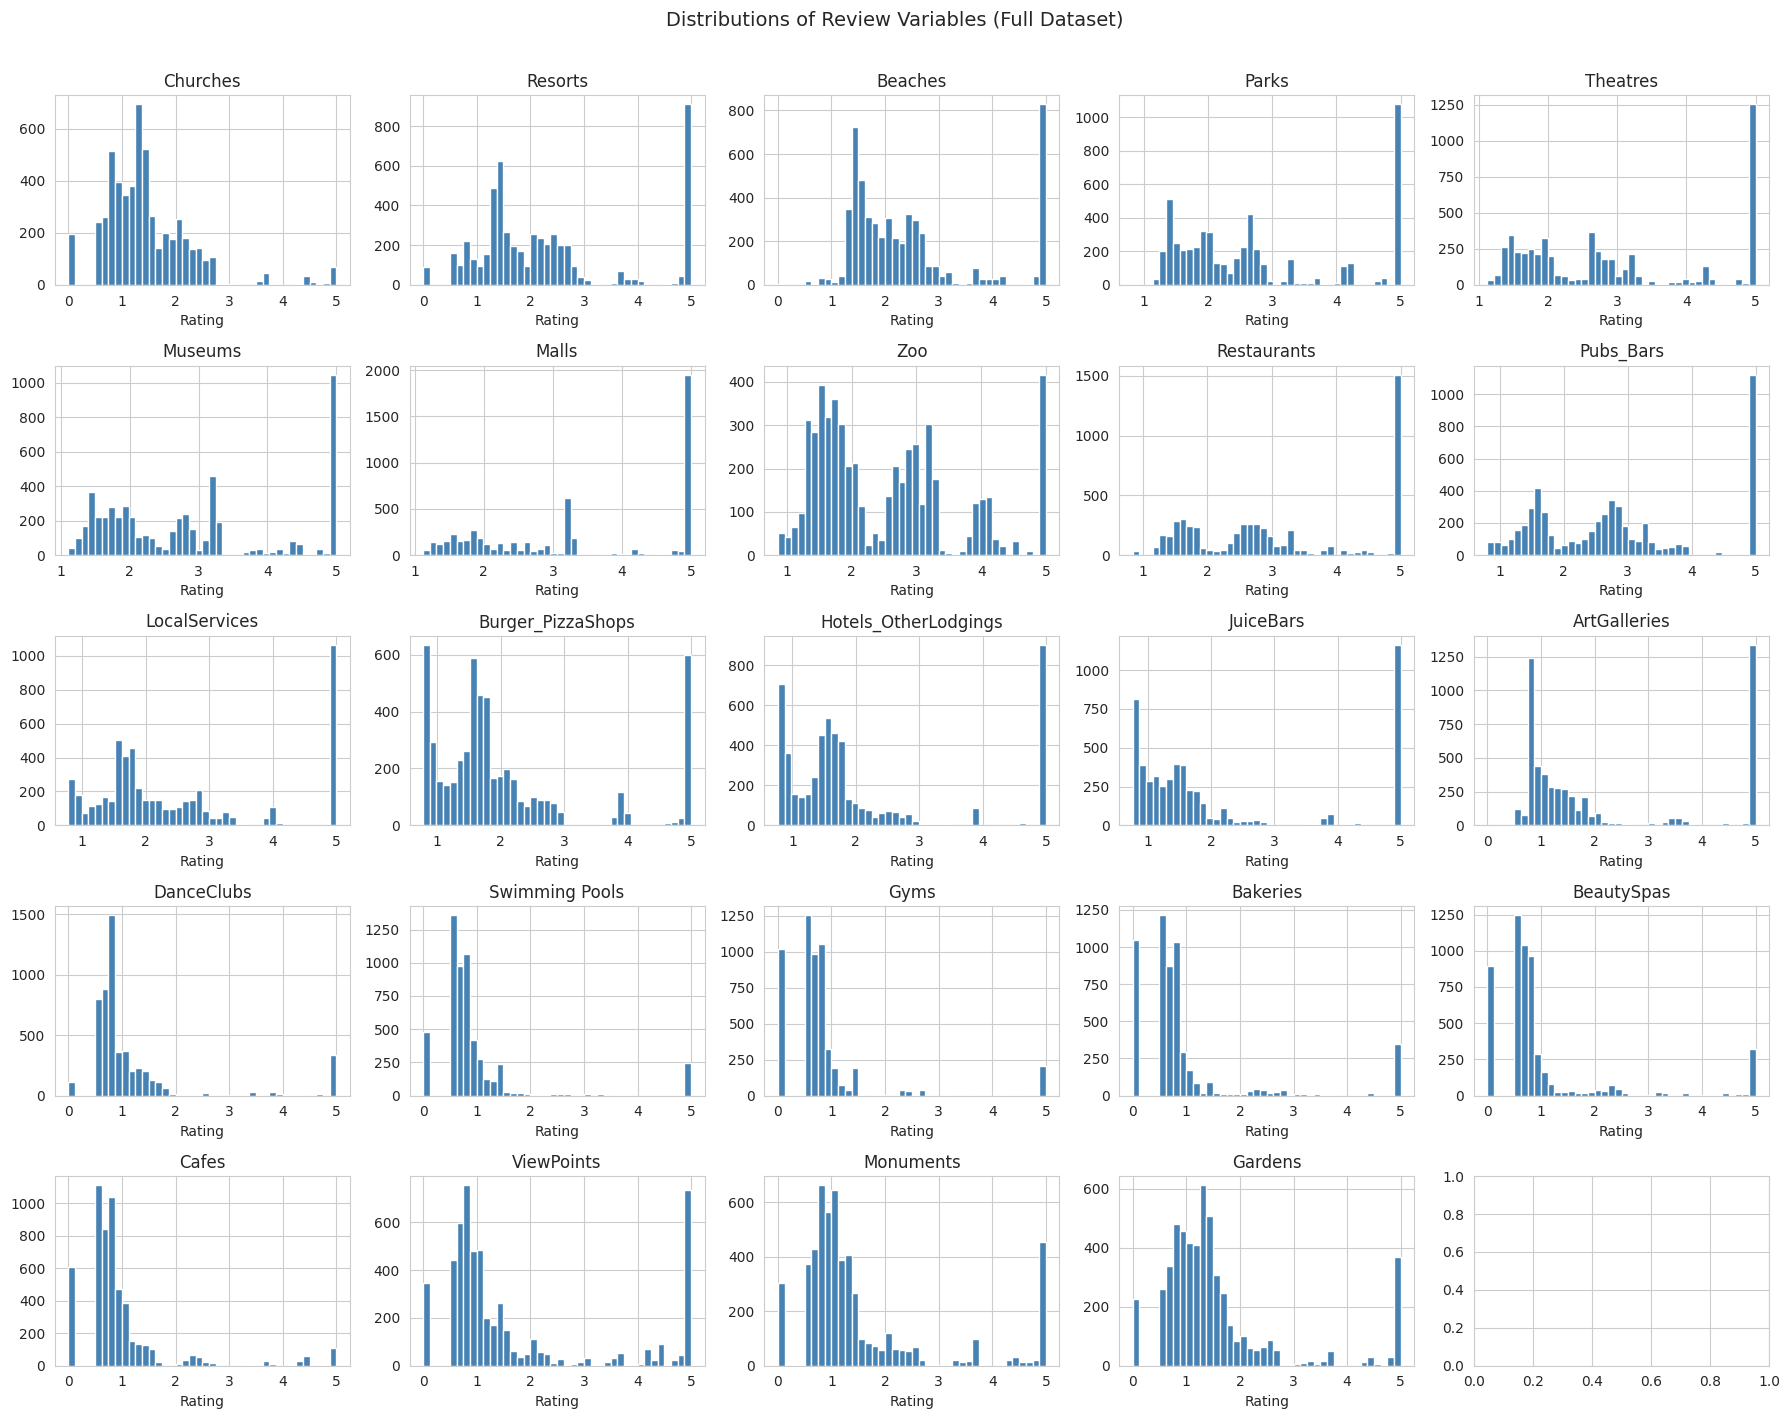

In [12]:
df_reviews.describe().round(1)

fig, axes = plt.subplots(5, 5, figsize=(18, 14))
for ax, col in zip(axes.ravel(), reviews_cols):
    ax.hist(df_reviews[col], bins=40, edgecolor="white", color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("Rating")
fig.suptitle("Distributions of Review Variables (Full Dataset)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [13]:
# ---------------------------------------------------
# t-SNE & UMAP (on full data)
# ---------------------------------------------------

# 1) Ensure numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 2) Treat missing as 0
X = X.fillna(0)

# 3) Drop constant columns
stds = X.std(axis=0)
constant_cols = stds[stds == 0].index.tolist()
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X = X.drop(columns=constant_cols)

# 4) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Safety check
print("Any NaNs in X_scaled?", np.isnan(X_scaled).any())
print("Shape:", X_scaled.shape)

Any NaNs in X_scaled? False
Shape: (5358, 24)


### t-SNE

In [14]:
# t-SNE
TSNE_PERPLEXITY = 30
TSNE_LEARNING_RATE = "auto"
TSNE_N_ITER = 1500
RANDOM_STATE = 42

tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    learning_rate=TSNE_LEARNING_RATE,
    max_iter=TSNE_N_ITER,
    init="pca",
    random_state=RANDOM_STATE
)

tsne_2d = tsne.fit_transform(X_scaled)
tsne_2d.shape

(5358, 2)

### UMAP

In [15]:
# UMAP
UMAP_N_NEIGHBORS = 25
UMAP_MIN_DIST = 0.10
UMAP_METRIC = "euclidean"

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE
)

umap_2d = umap_model.fit_transform(X_scaled)
umap_2d.shape

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(5358, 2)

In [16]:
# Cluster on embedding
K = 8
kmeans_tsne = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto").fit(tsne_2d)
kmeans_umap = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto").fit(umap_2d)

labels_tsne = kmeans_tsne.labels_
labels_umap = kmeans_umap.labels_

(labels_tsne[:10], labels_umap[:10])

(array([5, 5, 5, 5, 7, 5, 5, 5, 5, 5], dtype=int32),
 array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32))

### Cluster Analysis

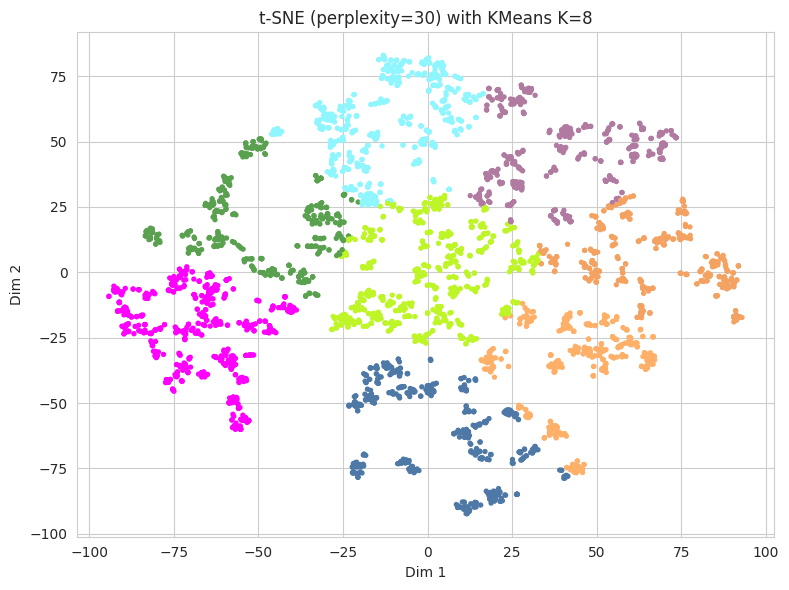

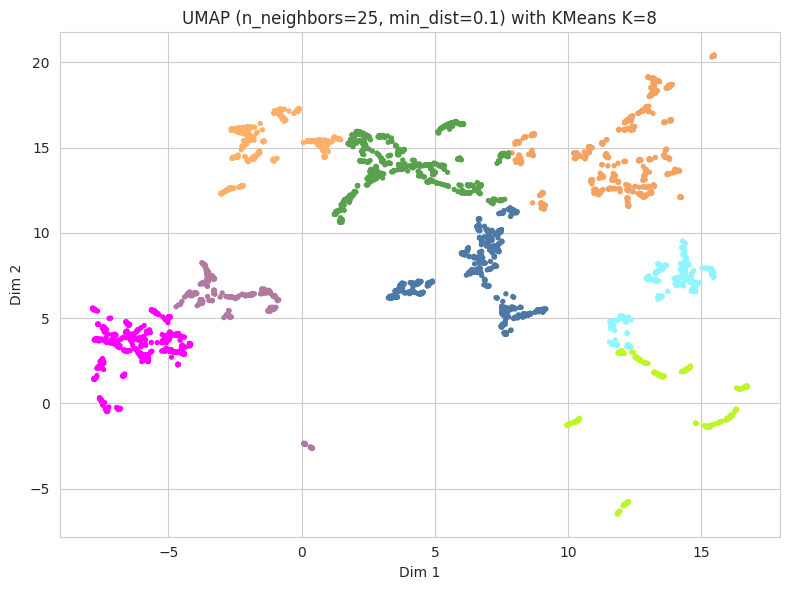

In [17]:
# Plotting
def scatter_plot(emb, labels=None, title="Embedding"):
    plt.figure(figsize=(8, 6))

    if labels is None:
        plt.scatter(emb[:, 0], emb[:, 1], s=8, color="gray")
    else:
        colors = ["#4E79A7", "#B07AA1", "#59A14F", "#F4A261", "#ffb068", "#8ff6ff", "#ff00ff", "#BEF527"]   # NEED TO ADD MORE COLORS
        cmap = ListedColormap(colors)
        plt.scatter(emb[:, 0], emb[:, 1], s=8, c=labels, cmap=cmap)

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()

scatter_plot(tsne_2d, labels_tsne, f"t-SNE (perplexity={TSNE_PERPLEXITY}) with KMeans K={K}")
scatter_plot(umap_2d, labels_umap, f"UMAP (n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}) with KMeans K={K}")

In [18]:
# Average ratings per cluster (using UMAP clusters)
profile = df.copy()
profile["cluster"] = labels_umap

cluster_means = profile.groupby("cluster")[reviews_cols].mean()
cluster_sizes = profile["cluster"].value_counts().sort_index()

display(cluster_sizes)
display(cluster_means)

,count
cluster,
0,795
1,427
2,943
3,986
4,536
5,489
6,739
7,443


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.638717,2.356553,2.460289,3.584101,4.183686,3.300239,3.368101,2.746289,2.901811,2.797887,...,1.215962,0.913082,0.870805,0.787811,0.794478,0.730906,0.727736,2.048667,2.122830,2.252151
1,2.487119,3.270023,3.041358,2.820000,2.575199,2.477330,2.631358,1.841241,2.764098,1.865269,...,2.417494,1.535550,0.817916,0.817869,1.845410,2.868782,0.942459,1.945761,1.335269,1.765597
2,1.199947,3.101760,3.427911,3.595557,3.856416,3.694984,3.937444,2.483457,3.181686,2.916554,...,2.610085,1.454136,0.556787,0.371145,0.368197,0.583871,0.662683,0.947646,1.000085,1.129449
3,1.020517,2.398925,1.985051,2.040588,2.416389,3.445710,4.693692,3.512049,4.584199,3.542728,...,2.513509,0.667191,0.586643,0.559442,0.670183,0.805822,0.863469,0.938509,0.948114,0.978245
4,1.458246,2.027687,3.330560,4.392966,4.178545,3.440709,2.795597,2.032481,2.283899,2.386511,...,1.157892,1.193843,0.909049,0.631306,0.565037,0.692369,1.260261,4.069328,2.734515,1.828825
5,1.186483,1.352822,1.567975,2.021329,2.229693,2.378896,3.433661,3.551002,4.324560,4.371902,...,1.245440,0.922311,0.699980,0.458855,0.272045,0.274519,0.444274,1.296912,0.921268,1.154213
6,2.317740,2.427930,2.259648,2.067767,1.925940,1.743221,1.902774,1.596387,1.689770,1.643505,...,2.370812,1.876806,2.118863,2.246725,2.383248,1.730000,2.135995,2.871340,2.685792,2.745413
7,0.811851,1.103567,1.639345,1.608420,1.623341,1.647156,2.885937,1.949481,2.727562,2.868330,...,4.273160,1.204515,1.200406,0.639887,1.272348,1.128623,0.758668,0.745214,0.708533,0.819594


### Comparison

In [19]:
# t-SNE cluster profiling
cluster_profile_tsne = df.copy()
cluster_profile_tsne["cluster"] = labels_tsne
means_tsne = cluster_profile_tsne.groupby("cluster")[reviews_cols].mean()
means_tsne

,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.102965,1.395567,1.885961,2.232254,2.232920,1.986384,2.965537,2.340242,3.178018,3.145552,...,2.950257,1.503056,1.149939,0.773812,1.024312,0.942572,0.666793,1.634387,1.292890,1.050408
1,0.986997,3.704121,2.045335,2.144760,2.559553,3.527204,4.676917,2.752396,4.337268,2.835783,...,2.861901,0.680000,0.647508,0.654521,0.724776,0.760575,0.865527,0.881789,0.890607,0.935160
2,2.054577,2.898559,3.370577,3.533640,3.205568,2.647874,2.532919,1.878883,2.703874,2.119063,...,1.778324,1.184198,0.881063,0.797423,1.551117,2.429351,1.290396,3.100108,2.295784,1.681694
3,1.090088,1.307504,2.150991,2.087239,2.310549,3.381947,4.590637,3.986248,4.837504,4.098354,...,2.857646,0.661735,0.545487,0.490832,0.580212,0.828566,0.847681,1.001717,1.025204,1.053965
4,1.272875,1.405099,1.652405,2.066166,2.223382,2.320886,3.446528,3.360651,4.069403,4.136691,...,2.190687,1.177432,0.627251,0.319078,0.342315,0.350705,0.598029,1.314159,1.026257,1.238698
5,1.288562,3.206879,4.081316,4.315604,4.420421,3.689742,3.142741,2.287313,2.608385,2.768820,...,1.635319,1.375848,0.630434,0.328548,0.323962,0.498100,0.730244,1.952619,1.012429,1.234288
6,2.392071,2.541919,2.330864,2.107598,1.962694,1.774066,1.907382,1.588933,1.687726,1.623126,...,2.281436,1.810356,2.038361,2.164562,2.297446,1.710064,2.057128,2.769149,2.573787,2.862745
7,1.484657,2.130297,2.315011,3.546144,4.259062,3.762471,3.882895,2.613158,2.577632,2.534108,...,1.439245,1.009119,0.793879,0.709943,0.723970,0.700824,0.685435,1.466751,1.997529,2.121716


In [20]:
# UMAP cluster profiling (again)
cluster_profile_umap = df.copy()
cluster_profile_umap["cluster"] = labels_umap
cluster_means_umap = cluster_profile_umap.groupby("cluster")[reviews_cols].mean()
cluster_sizes_umap = cluster_profile_umap["cluster"].value_counts()
display(cluster_sizes_umap)
display(cluster_means_umap)

,count
cluster,
3,986
2,943
0,795
6,739
4,536
5,489
7,443
1,427


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.638717,2.356553,2.460289,3.584101,4.183686,3.300239,3.368101,2.746289,2.901811,2.797887,...,1.215962,0.913082,0.870805,0.787811,0.794478,0.730906,0.727736,2.048667,2.122830,2.252151
1,2.487119,3.270023,3.041358,2.820000,2.575199,2.477330,2.631358,1.841241,2.764098,1.865269,...,2.417494,1.535550,0.817916,0.817869,1.845410,2.868782,0.942459,1.945761,1.335269,1.765597
2,1.199947,3.101760,3.427911,3.595557,3.856416,3.694984,3.937444,2.483457,3.181686,2.916554,...,2.610085,1.454136,0.556787,0.371145,0.368197,0.583871,0.662683,0.947646,1.000085,1.129449
3,1.020517,2.398925,1.985051,2.040588,2.416389,3.445710,4.693692,3.512049,4.584199,3.542728,...,2.513509,0.667191,0.586643,0.559442,0.670183,0.805822,0.863469,0.938509,0.948114,0.978245
4,1.458246,2.027687,3.330560,4.392966,4.178545,3.440709,2.795597,2.032481,2.283899,2.386511,...,1.157892,1.193843,0.909049,0.631306,0.565037,0.692369,1.260261,4.069328,2.734515,1.828825
5,1.186483,1.352822,1.567975,2.021329,2.229693,2.378896,3.433661,3.551002,4.324560,4.371902,...,1.245440,0.922311,0.699980,0.458855,0.272045,0.274519,0.444274,1.296912,0.921268,1.154213
6,2.317740,2.427930,2.259648,2.067767,1.925940,1.743221,1.902774,1.596387,1.689770,1.643505,...,2.370812,1.876806,2.118863,2.246725,2.383248,1.730000,2.135995,2.871340,2.685792,2.745413
7,0.811851,1.103567,1.639345,1.608420,1.623341,1.647156,2.885937,1.949481,2.727562,2.868330,...,4.273160,1.204515,1.200406,0.639887,1.272348,1.128623,0.758668,0.745214,0.708533,0.819594


### PCA

In [21]:
# ---------------------------------------------------
# PCA (on full data, no hold-out)
# ---------------------------------------------------

meta_groups = {
    "Cultural_Heritage": ["Churches", "Museums", "Theatres", "ArtGalleries", "Monuments", "ViewPoints"],
    "Nature_Outdoor": ["Parks", "Beaches", "Gardens", "Zoo"],
    "Shopping": ["Malls", "Bakeries", "LocalServices"],
    "Food_Beverage": ["Restaurants", "Pubs_Bars", "Burger_PizzaShops", "Cafes", "JuiceBars"],
    "Accommodation": ["Hotels_OtherLodgings", "Resorts"],
    "Recreation_Wellness": ["DanceClubs", "Swimming Pools", "Gyms", "BeautySpas"],
}

meta_df = pd.DataFrame(index=df.index)
for name, cols in meta_groups.items():
    meta_df[name] = df[cols].mean(axis=1)

meta_df.describe()

,Cultural_Heritage,Nature_Outdoor,Shopping,Food_Beverage,Accommodation,Recreation_Wellness
count,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000
mean,2.151072,2.360315,2.289737,2.234245,2.227384,0.994448
std,0.580685,0.627056,0.678229,0.641303,0.887798,0.685379
min,0.605000,0.845000,0.980000,0.862000,0.730000,0.000000
25%,1.768333,1.915625,1.683333,1.706000,1.470000,0.625000
50%,2.128333,2.290000,2.390000,2.228000,1.880000,0.785000
75%,2.526667,2.782500,2.770000,2.760000,3.170000,0.977500
max,4.173333,4.457500,5.000000,4.022000,5.000000,4.160000


Text(0.5, 1.0, 'Scree plot')

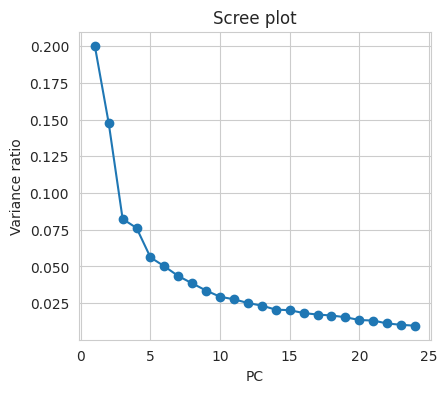

In [22]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(df_reviews)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.xlabel("PC")
plt.ylabel("Variance ratio")
plt.title("Scree plot")

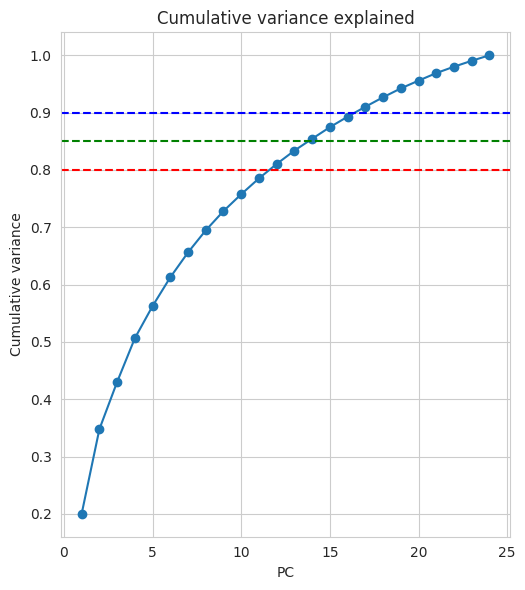

In [23]:
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker='o')
plt.axhline(0.8, color='r', ls='--')
plt.axhline(0.85, color='g', ls='--')
plt.axhline(0.9, color='b', ls='--')
plt.xlabel("PC")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance explained")
plt.tight_layout()
plt.show()


Top 10 features for PC1:
ViewPoints              0.375772
JuiceBars              -0.312156
Monuments               0.275690
ArtGalleries           -0.266760
Restaurants            -0.266641
Pubs_Bars              -0.237478
Hotels_OtherLodgings   -0.236265
Malls                  -0.230609
Gardens                 0.222590
Parks                   0.221754
Name: PC1, dtype: float64

Top 10 features for PC2:
Museums         0.332574
Theatres        0.314533
ArtGalleries   -0.311981
JuiceBars      -0.291488
Bakeries       -0.288443
Malls           0.279021
Parks           0.240154
Zoo             0.227032
Restaurants     0.224800
BeautySpas     -0.216090
Name: PC2, dtype: float64

Top 10 features for PC3:
LocalServices    0.376783
Pubs_Bars        0.338695
JuiceBars       -0.313596
ViewPoints       0.313200
Theatres        -0.282879
Museums         -0.278980
Beaches         -0.265390
Resorts         -0.237437
Restaurants      0.220840
ArtGalleries    -0.206135
Name: PC3, dtype: float64


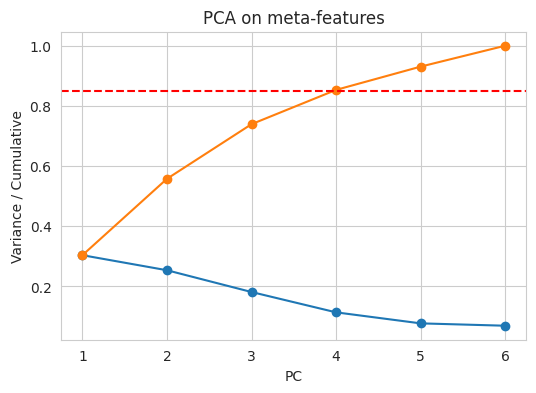

,PC1,PC2,PC3,PC4,PC5,PC6
Cultural_Heritage,-0.272629,0.365896,-0.093389,0.277415,0.496002,0.678303
Nature_Outdoor,-0.192595,0.441232,-0.405548,0.321548,0.228112,-0.669570
Shopping,0.344415,-0.401431,-0.212216,0.802777,-0.142752,0.101818
Food_Beverage,0.451347,-0.323903,-0.056516,-0.212181,0.789294,-0.142035
Accommodation,0.743235,0.635992,0.131457,-0.000950,-0.140963,0.077220
Recreation_Wellness,-0.117672,0.029810,0.872525,0.360799,0.196757,-0.234684


In [24]:
pca = PCA(n_components=n_pcs)
X_pca = pca.fit_transform(df_reviews)

loadings = pd.DataFrame(
    pca.components_.T,
    index=reviews_cols,
    columns=[f"PC{i+1}" for i in range(n_pcs)]
)

for i in range(min(3, n_pcs)):
    pc = f"PC{i+1}"
    print(f"\nTop 10 features for {pc}:")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(10))

# PCA on meta features
pca_meta = PCA()
X_meta_pca = pca_meta.fit_transform(meta_df)

meta_expl = pca_meta.explained_variance_ratio_
meta_cum = np.cumsum(meta_expl)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(meta_expl) + 1), meta_expl, marker='o')
plt.plot(range(1, len(meta_cum) + 1), meta_cum, marker='o')
plt.axhline(0.85, color='r', ls='--')
plt.xlabel("PC")
plt.ylabel("Variance / Cumulative")
plt.title("PCA on meta-features")
plt.grid(True)
plt.show()

meta_loadings = pd.DataFrame(
    pca_meta.components_.T,
    index=meta_df.columns,
    columns=[f"PC{i+1}" for i in range(len(meta_expl))]
)
meta_loadings

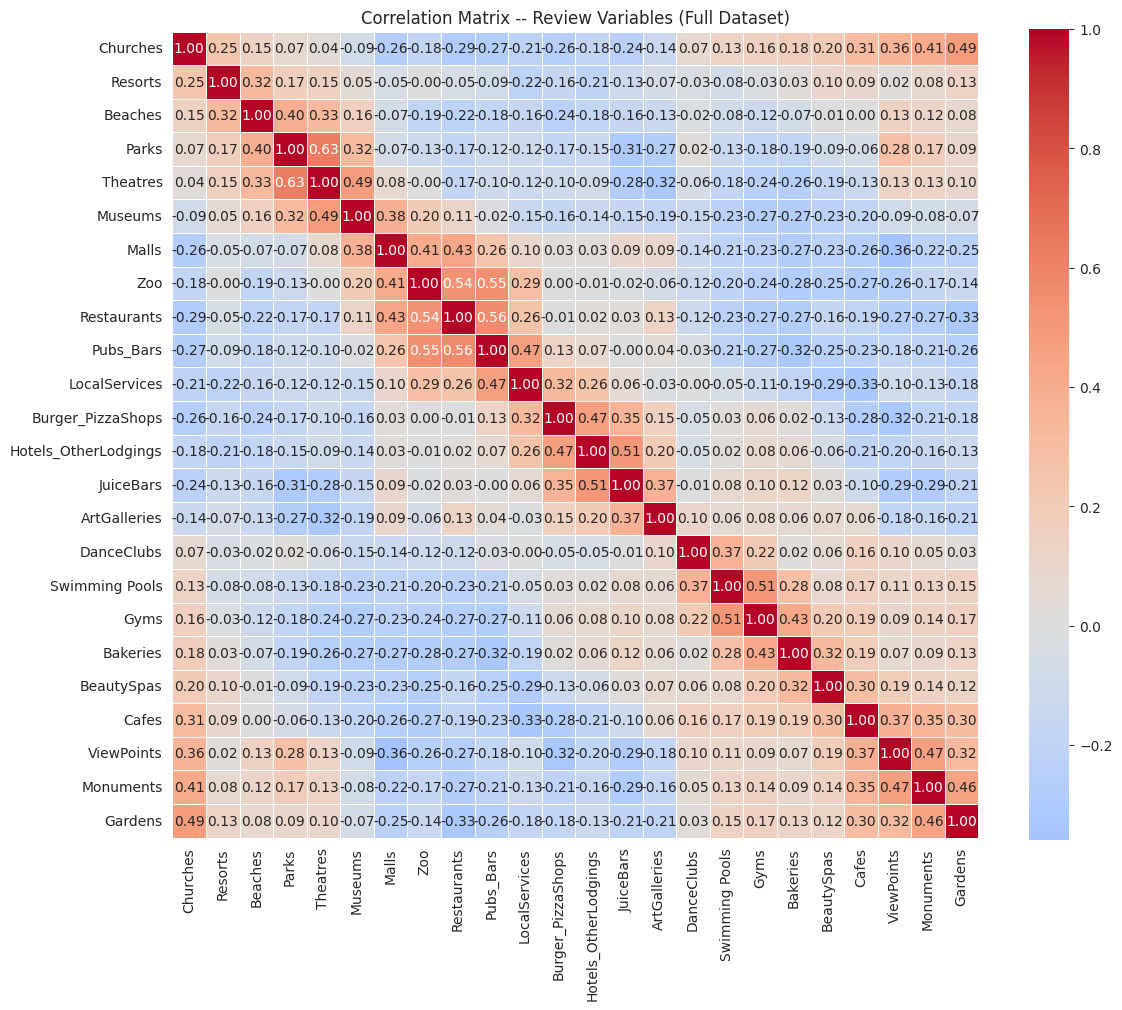

In [25]:
corr = df_reviews.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix -- Review Variables (Full Dataset)")
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering
---
---

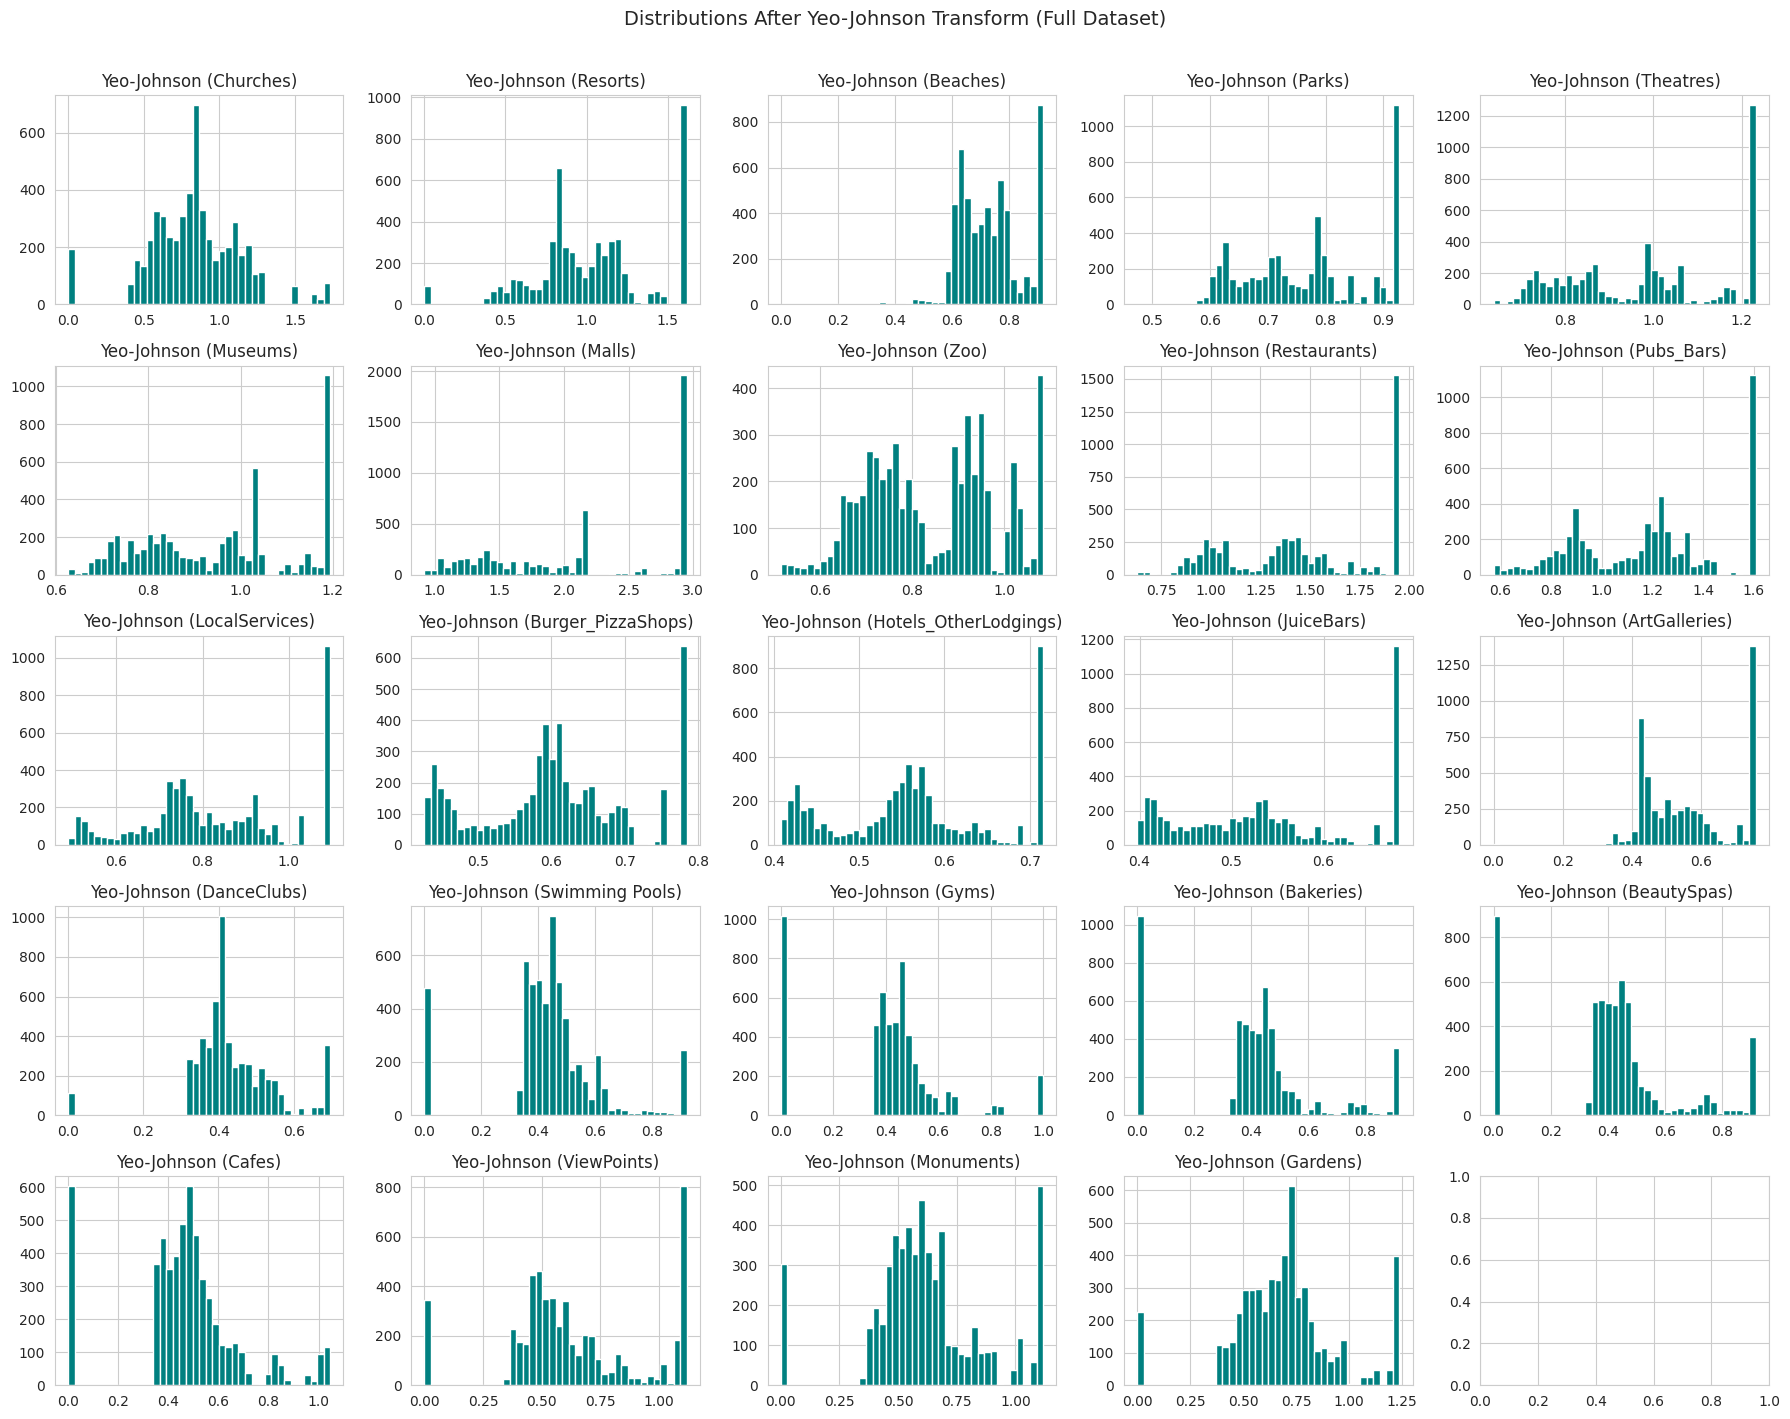

In [26]:
# Step 4: Feature Engineering on full data
pt = PowerTransformer(method='yeo-johnson', standardize=False)

X_yj = df_reviews.copy()
X_yj[reviews_cols] = pt.fit_transform(df_reviews[reviews_cols])

fig, axes = plt.subplots(5, 5, figsize=(18, 14))
for ax, col in zip(axes.ravel(), reviews_cols):
    ax.hist(X_yj[col], bins=40, edgecolor="white", color="teal")
    ax.set_title(f"Yeo-Johnson ({col})")
fig.suptitle("Distributions After Yeo-Johnson Transform (Full Dataset)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [27]:
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_yj)

X_scaled_full = pd.DataFrame(X_scaled_full, columns=reviews_cols, index=df_reviews.index)

print("Scaled full set -- means and std devs:")
print(X_scaled_full.describe().loc[["mean", "std"]].round(4))

Scaled full set -- means and std devs:
      Churches  Resorts  Beaches   Parks  Theatres  Museums   Malls     Zoo  \
mean   -0.0000   0.0000   0.0000  0.0000    0.0000   0.0000  0.0000  0.0000   
std     1.0001   1.0001   1.0001  1.0001    1.0001   1.0001  1.0001  1.0001   

      Restaurants  Pubs_Bars  ...  ArtGalleries  DanceClubs  Swimming Pools  \
mean       0.0000    -0.0000  ...       -0.0000      0.0000         -0.0000   
std        1.0001     1.0001  ...        1.0001      1.0001          1.0001   

        Gyms  Bakeries  BeautySpas   Cafes  ViewPoints  Monuments  Gardens  
mean -0.0000    0.0000     -0.0000 -0.0000     -0.0000    -0.0000  -0.0000  
std   1.0001    1.0001      1.0001  1.0001      1.0001     1.0001   1.0001  

[2 rows x 24 columns]


In [28]:
meta_scaler = StandardScaler()
X_meta_scaled = meta_scaler.fit_transform(meta_df.values)

## Step 5: Clustering
---
---

### k-Means

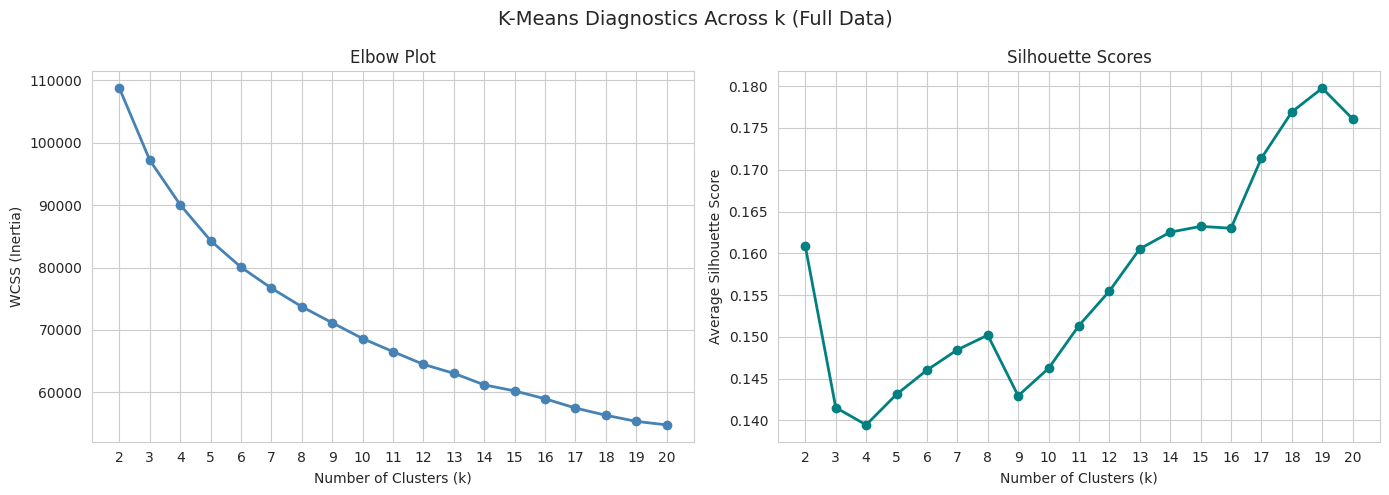

In [29]:
# Step 5: K-Means model selection on full data
K_range = range(2, 21)
wcss_scores = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_scaled_full)
    wcss_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_full, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, wcss_scores, "o-", color="steelblue", linewidth=2)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("WCSS (Inertia)")
ax1.set_title("Elbow Plot")
ax1.set_xticks(list(K_range))

ax2.plot(K_range, sil_scores, "o-", color="teal", linewidth=2)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_title("Silhouette Scores")
ax2.set_xticks(list(K_range))

fig.suptitle("K-Means Diagnostics Across k (Full Data)", fontsize=14)
fig.tight_layout()
plt.show()

In [30]:
# Choose candidate k
k_7 = 7
print(f"Selected k = {k_7}")
print(f"  WCSS:       {wcss_scores[k_7 - 2]:.1f}")
print(f"  Silhouette: {sil_scores[k_7 - 2]:.4f}")

km_7 = KMeans(n_clusters=k_7, n_init=20, random_state=RANDOM_SEED)
labels_7 = km_7.fit_predict(X_scaled_full)
print("Cluster sizes (k=7, full data):")
print(pd.Series(labels_7).value_counts().sort_index())

Selected k = 7
  WCSS:       76687.6
  Silhouette: 0.1484
Cluster sizes (k=7, full data):
0     519
1    1132
2     951
3     420
4     849
5     852
6     732
Name: count, dtype: int64


In [31]:
k_9 = 9
print(f"Selected k = {k_9}")
print(f"  WCSS:       {wcss_scores[k_9 - 2]:.1f}")
print(f"  Silhouette: {sil_scores[k_9 - 2]:.4f}")

Selected k = 9
  WCSS:       71146.1
  Silhouette: 0.1429


In [32]:
k_8 = 8
print(f"Selected k = {k_8}")
print(f"  WCSS:       {wcss_scores[k_8 - 2]:.1f}")
print(f"  Silhouette: {sil_scores[k_8 - 2]:.4f}")

km_8 = KMeans(n_clusters=k_8, n_init=20, random_state=RANDOM_SEED)
labels_8 = km_8.fit_predict(X_scaled_full)
print("Cluster sizes (k=8, full data):")
print(pd.Series(labels_8).value_counts().sort_index())

k_chosen = 8
km_final = KMeans(n_clusters=k_chosen, n_init=20, random_state=RANDOM_SEED)
cluster_labels = km_final.fit_predict(X_scaled_full)

print("Cluster sizes (chosen k, full data):")
print(pd.Series(cluster_labels).value_counts().sort_index())

Selected k = 8
  WCSS:       73721.5
  Silhouette: 0.1502
Cluster sizes (k=8, full data):
0    829
1    498
2    838
3    256
4    793
5    733
6    516
7    992
Name: count, dtype: int64
Cluster sizes (chosen k, full data):
0    829
1    498
2    838
3    256
4    793
5    733
6    516
7    992
Name: count, dtype: int64


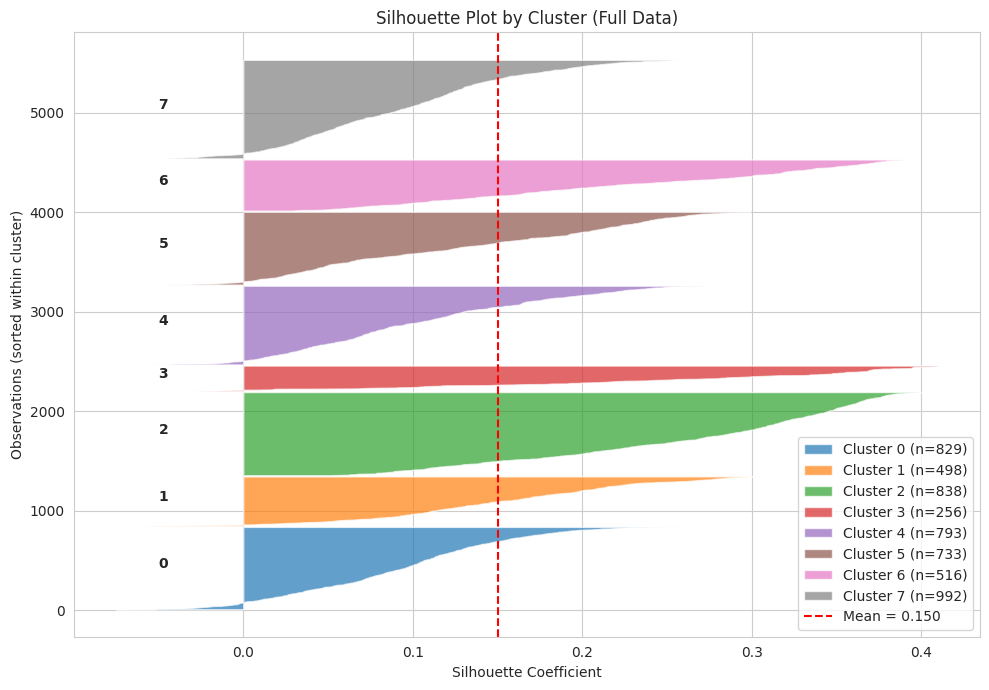

In [33]:
# Silhouette analysis on full data
sil_vals = silhouette_samples(X_scaled_full, cluster_labels)
avg_sil = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(k_chosen):
    cluster_sil = np.sort(sil_vals[cluster_labels == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     alpha=0.7, label=f"Cluster {i} (n={size_i})")
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontweight="bold")
    y_lower = y_upper + 10

ax.axvline(avg_sil, color="red", linestyle="--", label=f"Mean = {avg_sil:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Observations (sorted within cluster)")
ax.set_title("Silhouette Plot by Cluster (Full Data)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [34]:
n_neg = (sil_vals < 0).sum()
print(f"Points with negative silhouette: {n_neg} / {len(sil_vals)} ({100*n_neg/len(sil_vals):.1f}%)")

Points with negative silhouette: 213 / 5455 (3.9%)


In [35]:
# Stability via resampling on full data
B = 30
ari_scores = []

for b in range(B):
    idx = np.random.choice(X_scaled_full.index, size=int(0.8 * len(X_scaled_full)),
                           replace=False)
    X_sub = X_scaled_full.loc[idx]

    km_sub = KMeans(n_clusters=k_chosen, n_init=20, random_state=b)
    sub_labels = km_sub.fit_predict(X_sub)

    ref_labels = pd.Series(cluster_labels, index=X_scaled_full.index).loc[idx].values
    ari = adjusted_rand_score(ref_labels, sub_labels)
    ari_scores.append(ari)

print(f"Stability (ARI) over {B} runs:")
print(f"  Mean:   {np.mean(ari_scores):.3f}")
print(f"  Std:    {np.std(ari_scores):.3f}")
print(f"  Min:    {np.min(ari_scores):.3f}")
print(f"  Max:    {np.max(ari_scores):.3f}")


Stability (ARI) over 30 runs:
  Mean:   0.831
  Std:    0.067
  Min:    0.674
  Max:    0.912


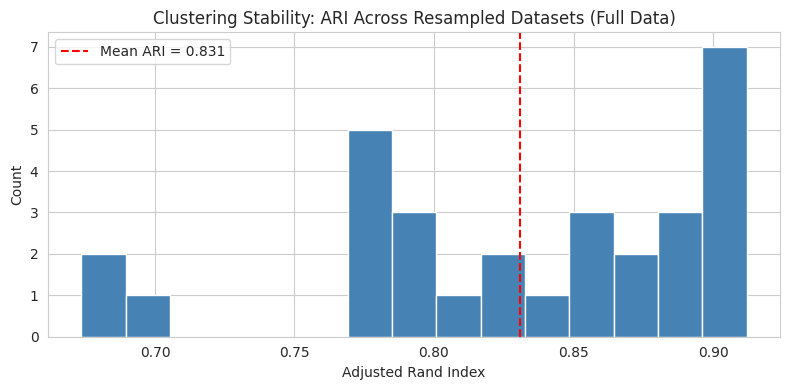

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(ari_scores, bins=15, edgecolor="white", color="steelblue")
plt.axvline(np.mean(ari_scores), color="red", linestyle="--",
            label=f"Mean ARI = {np.mean(ari_scores):.3f}")
plt.xlabel("Adjusted Rand Index")
plt.ylabel("Count")
plt.title("Clustering Stability: ARI Across Resampled Datasets (Full Data)")
plt.legend()
plt.tight_layout()
plt.show()

### Hierarchical

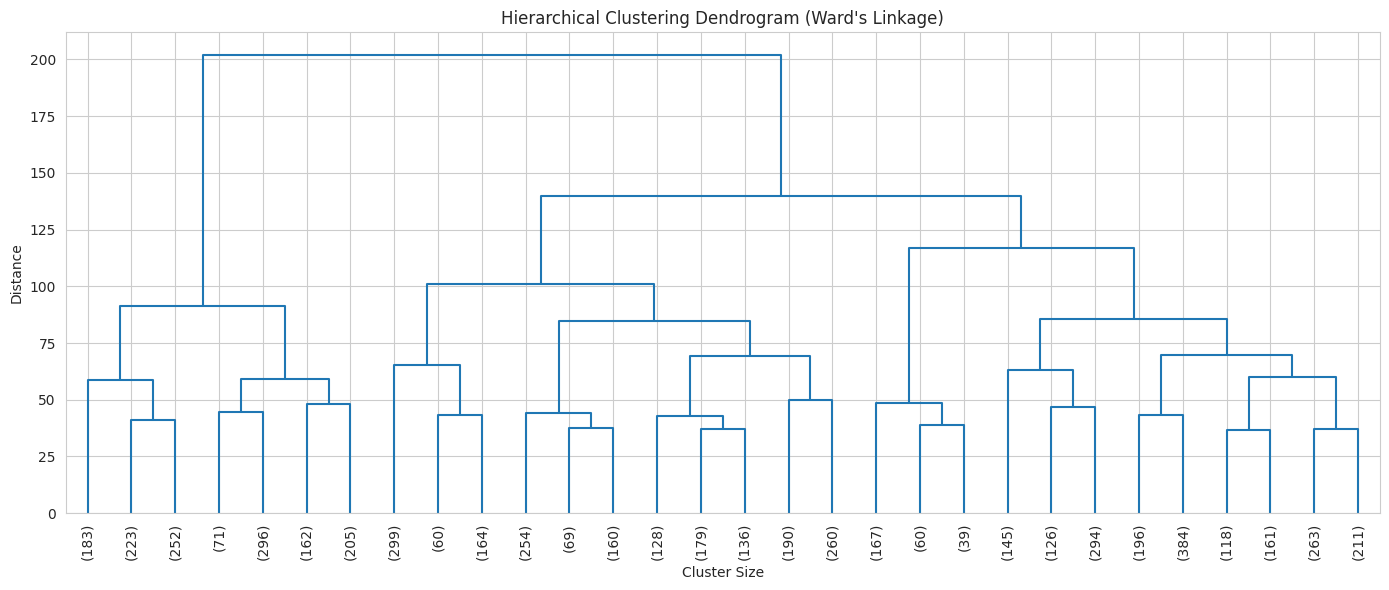

In [37]:
# ---------------------------------------------------
# Hierarchical Clustering (Full Data)
# ---------------------------------------------------

Z = linkage(X_scaled_full, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=10, color_threshold=0)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [38]:
hc = AgglomerativeClustering(n_clusters=k_chosen, linkage="ward")
hc_labels = hc.fit_predict(X_scaled_full)

ari_hc = adjusted_rand_score(cluster_labels, hc_labels)
print(f"ARI between K-Means and Hierarchical (Ward's): {ari_hc:.3f}")

print("\nCrosstab of K-Means vs. Hierarchical assignments:")
print(pd.crosstab(
    pd.Series(cluster_labels, name="K-Means"),
    pd.Series(hc_labels, name="Hierarchical")
))

ARI between K-Means and Hierarchical (Ward's): 0.505

Crosstab of K-Means vs. Hierarchical assignments:
Hierarchical    0    1    2    3    4    5    6    7
K-Means                                             
0              49  240    0    0   20    0  511    9
1               6   16    0   23   43    0    0  410
2               0    1    3    0    0  650  184    0
3               2    0   16  236    2    0    0    0
4             168  522    0    0    0    3   39   61
5             176   13  539    0    0    5    0    0
6             120    6    0    7  383    0    0    0
7             812   95    7    0   75    0    0    3


## Step 6: Interpretation and Evaluation
---
---

Cluster centers (standardized yeo-johnson-transformed features):


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.026,0.163,0.525,0.916,0.677,0.323,-0.451,-0.734,-0.503,-0.784,...,-0.509,-0.015,0.045,0.114,0.195,0.308,0.238,0.636,0.230,0.054
1,-0.160,0.307,1.081,1.035,1.135,1.023,0.312,-0.068,-0.326,0.094,...,-0.158,-0.247,-1.151,-1.603,-1.529,-1.147,-0.639,-0.295,-0.219,-0.204
2,1.216,0.391,0.147,-0.391,-0.691,-0.900,-1.088,-1.030,-1.172,-1.042,...,0.068,0.584,0.916,1.129,1.192,0.982,0.982,0.800,0.955,1.100
3,-2.227,-1.669,-1.014,-1.202,-1.176,-1.176,-0.642,-0.134,0.038,0.512,...,0.132,-0.129,0.352,0.381,0.413,-0.821,-1.958,-2.171,-2.426,-2.293
4,0.541,0.428,0.403,0.733,0.903,0.326,0.075,0.466,0.080,0.283,...,-0.421,0.052,0.022,0.149,0.155,0.112,-0.006,0.321,0.558,0.565
5,-0.476,-0.467,-0.461,-0.899,-1.004,-0.996,0.244,-0.134,0.257,0.406,...,0.915,0.157,0.213,0.134,0.026,0.153,0.163,-0.345,-0.360,-0.451
6,-0.018,-0.546,-0.798,-0.560,-0.411,-0.065,0.101,1.110,1.036,1.273,...,-0.473,-0.090,-0.602,-1.196,-1.272,-1.164,-0.719,-0.186,-0.149,-0.004
7,-0.422,0.098,-0.410,-0.275,-0.015,0.789,1.012,0.702,0.771,0.167,...,0.319,-0.434,-0.187,0.061,0.009,0.103,0.056,-0.405,-0.365,-0.397


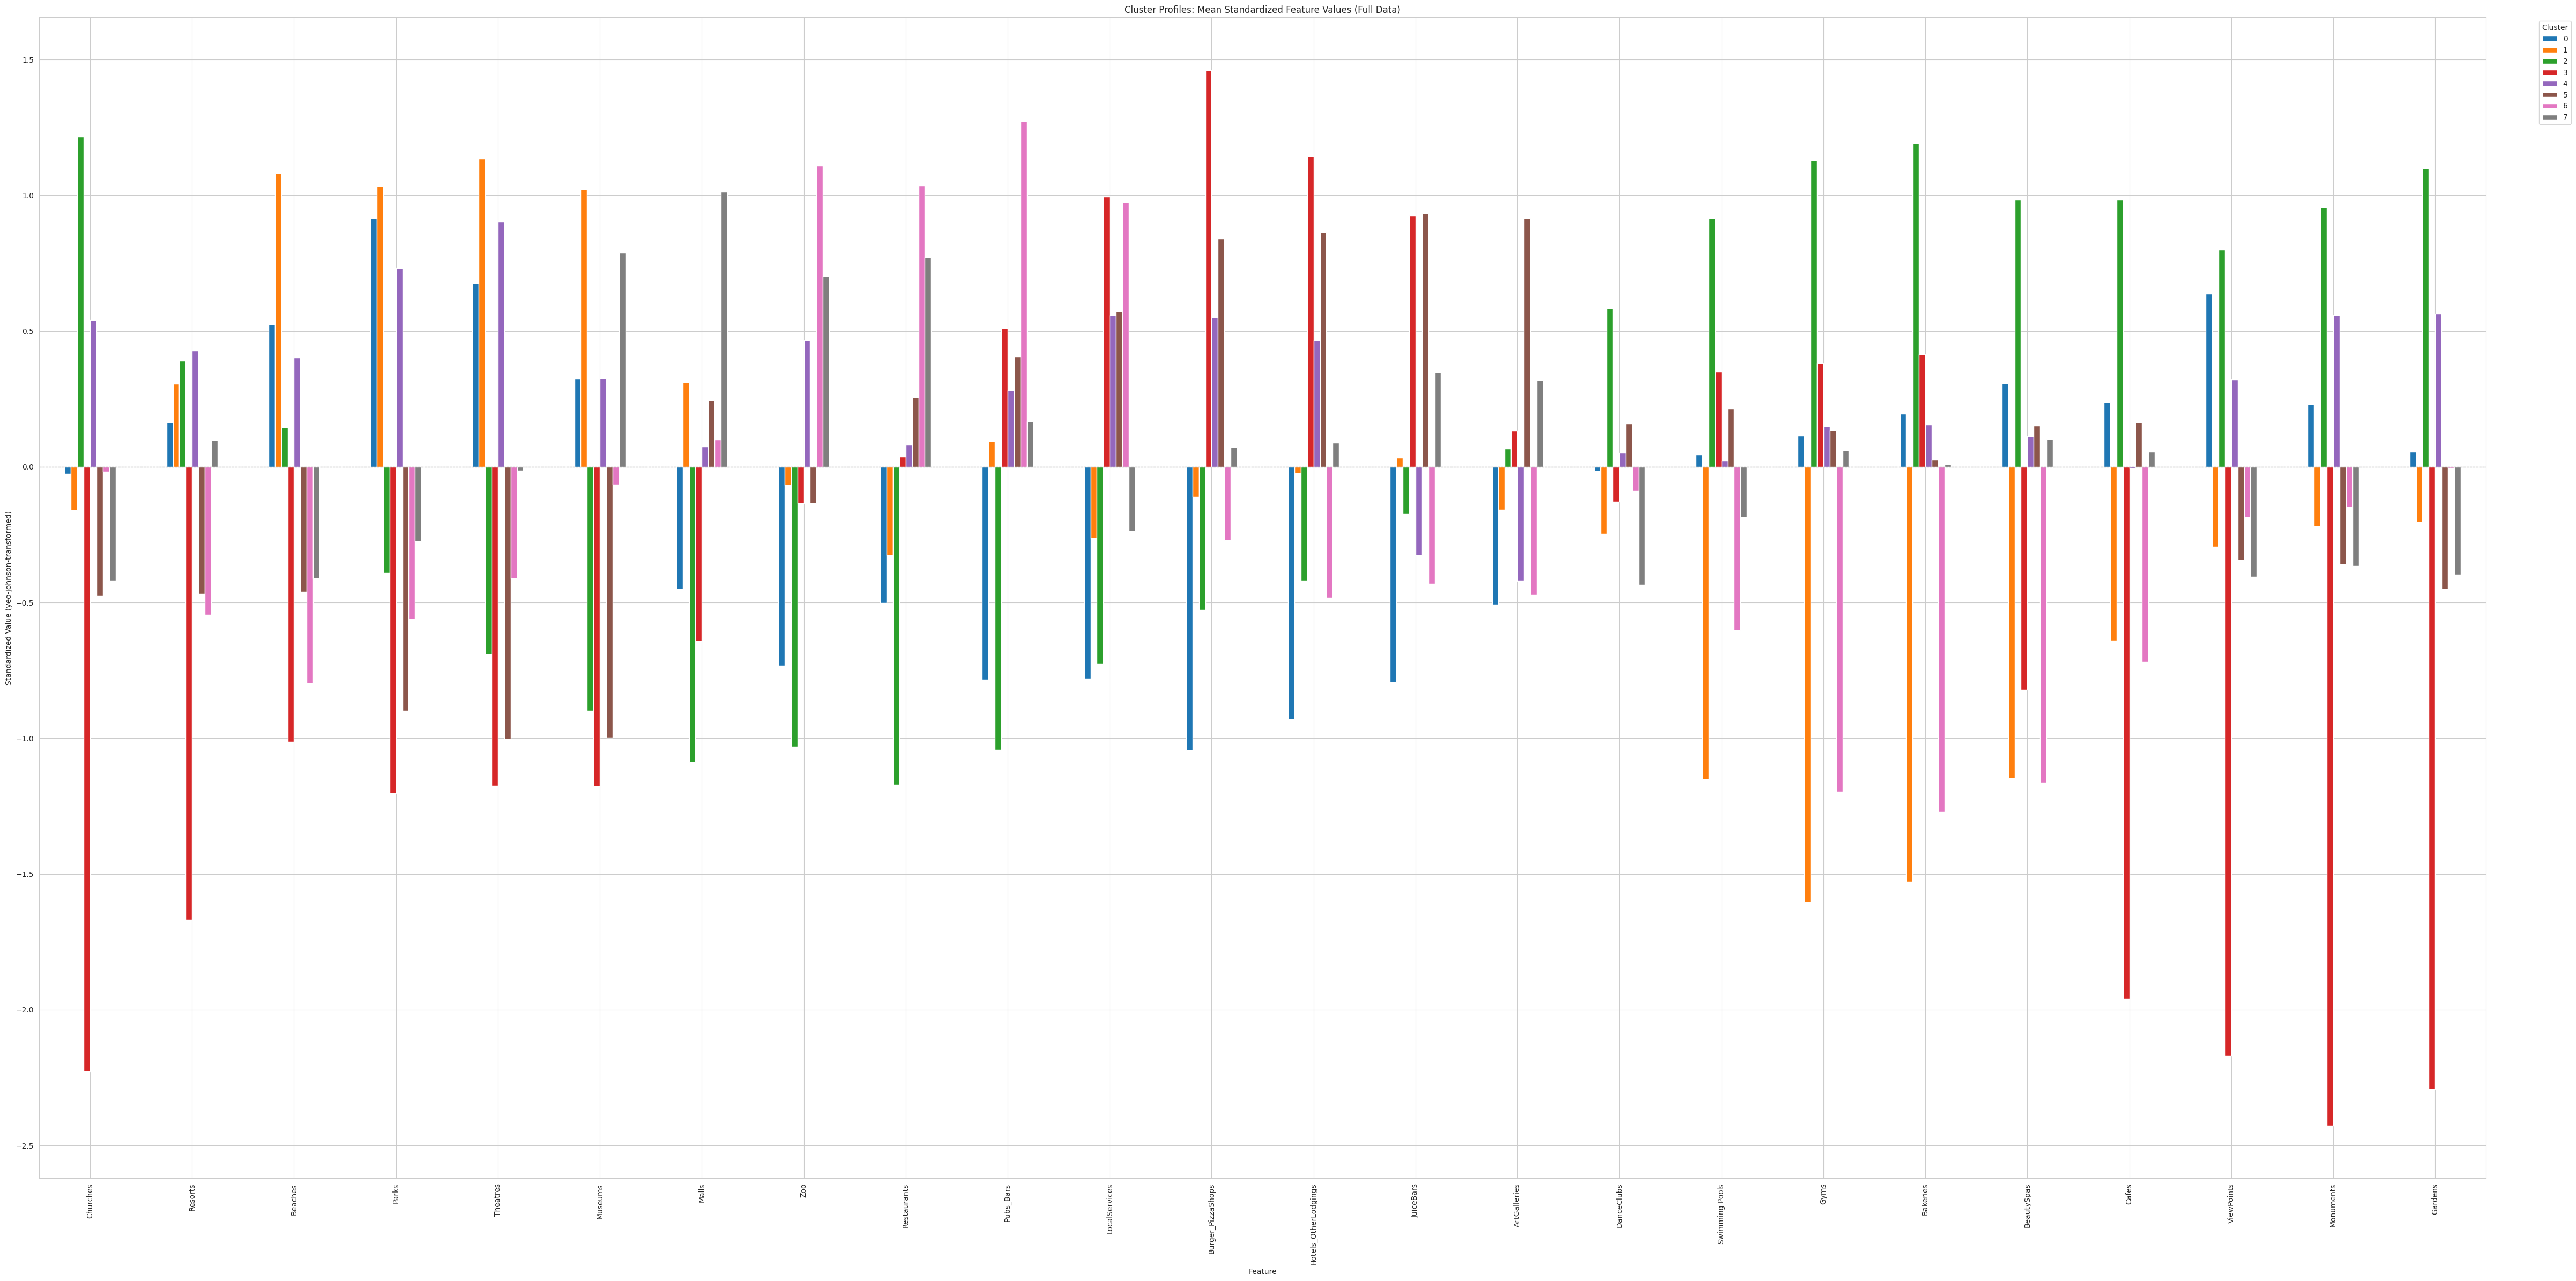

In [39]:
# ---------------------------------------------------
# Cluster Interpretation and Evaluation (Full Data)
# ---------------------------------------------------

# Means of scaled features by cluster
profile_scaled = X_scaled_full.copy()
profile_scaled["Cluster"] = cluster_labels

cluster_means_scaled = profile_scaled.groupby("Cluster")[reviews_cols].mean()
print("Cluster centers (standardized yeo-johnson-transformed features):")
display(cluster_means_scaled.round(3))

cluster_means_scaled.T.plot(kind="bar", figsize=(48, 24), edgecolor="white")
plt.title("Cluster Profiles: Mean Standardized Feature Values (Full Data)")
plt.ylabel("Standardized Value (yeo-johnson-transformed)")
plt.xlabel("Feature")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

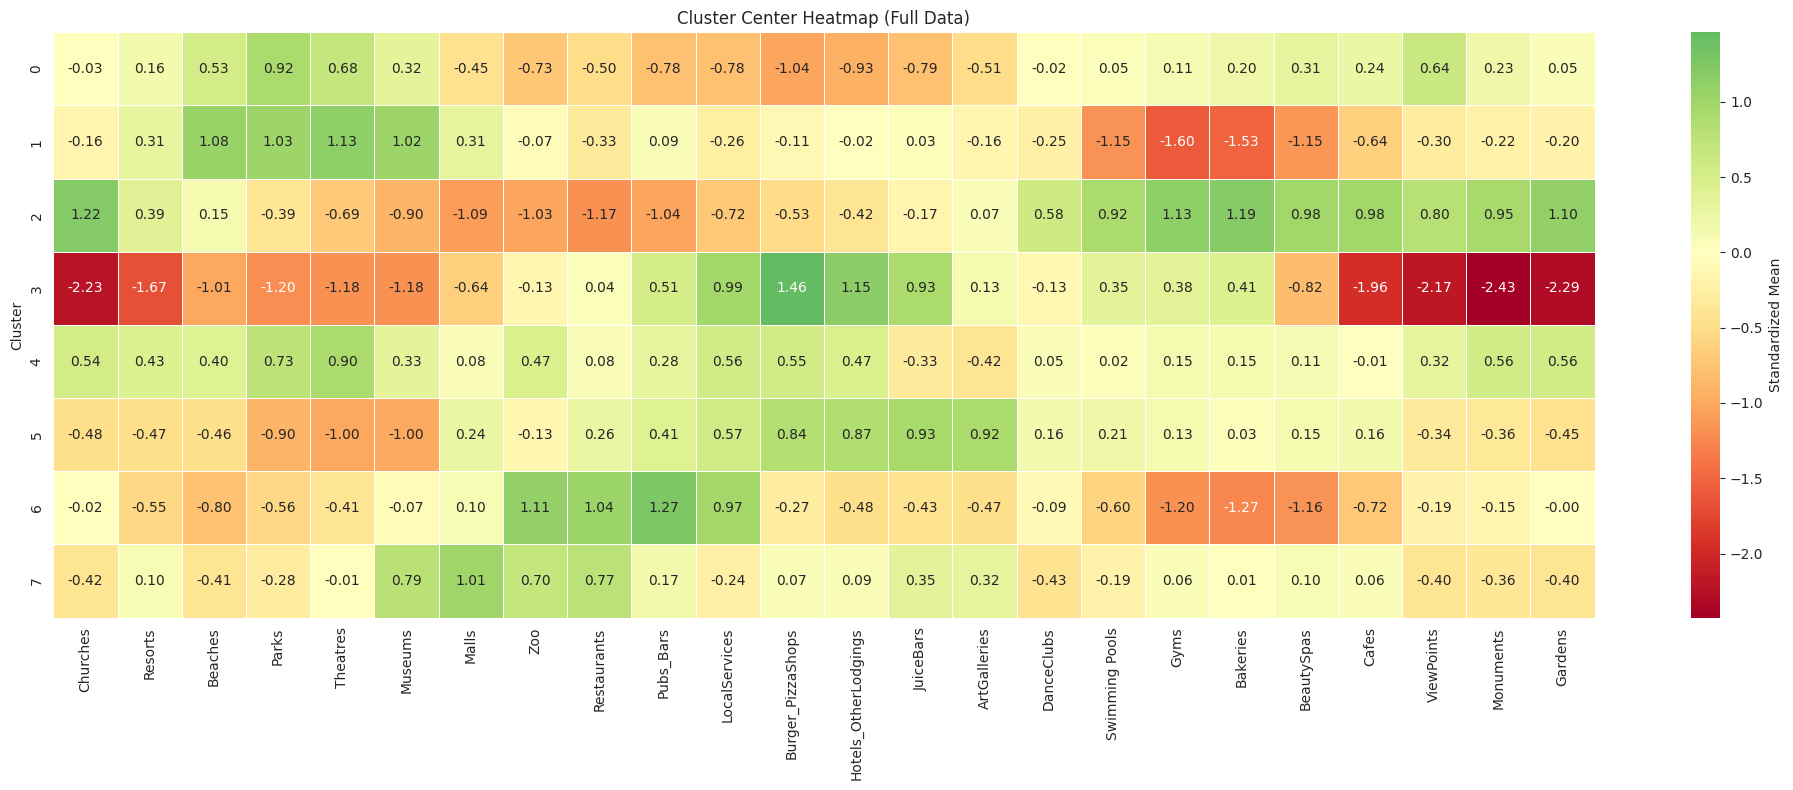

In [40]:
plt.figure(figsize=(20, 8))
sns.heatmap(cluster_means_scaled, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"label": "Standardized Mean"})
plt.title("Cluster Center Heatmap (Full Data)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


Cluster means in original units:


,Churches,Resorts,Beaches,Parks,Theatres,Museums,Malls,Zoo,Restaurants,Pubs_Bars,...,ArtGalleries,DanceClubs,Swimming Pools,Gyms,Bakeries,BeautySpas,Cafes,ViewPoints,Monuments,Gardens
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.4,2.5,3.2,4.0,3.8,3.3,2.7,1.8,2.5,2.0,...,1.4,1.1,0.8,0.7,1.0,1.3,1.1,2.9,1.9,1.5
1,1.3,2.9,4.1,4.1,4.5,4.3,3.8,2.3,2.6,2.9,...,1.5,1.1,0.5,0.0,0.0,0.2,0.6,1.3,1.1,1.2
2,2.5,2.6,2.4,2.2,2.0,1.8,1.9,1.5,1.7,1.6,...,2.2,1.6,1.7,1.9,2.5,2.1,2.0,2.8,2.6,2.8
3,0.2,0.7,1.6,1.6,1.7,1.6,2.5,2.3,3.0,3.3,...,2.7,0.9,1.1,1.1,1.6,0.6,0.0,0.0,0.0,0.2
4,1.9,2.8,2.8,3.8,4.2,3.1,3.4,2.9,3.1,3.0,...,1.5,1.2,0.8,0.7,0.7,0.8,0.8,2.3,2.4,2.2
5,1.1,1.7,2.0,1.7,1.7,1.7,3.7,2.3,3.4,3.2,...,3.9,1.7,1.3,1.0,0.8,1.0,0.9,1.0,1.0,1.0
6,1.3,1.4,1.6,2.2,2.4,2.7,3.4,3.8,4.6,4.6,...,1.3,1.1,0.6,0.2,0.1,0.2,0.5,1.4,1.1,1.3
7,1.1,2.6,2.0,2.3,2.8,3.9,4.8,3.4,4.2,3.1,...,2.8,0.8,0.7,0.7,0.7,0.9,0.8,0.9,0.9,1.1


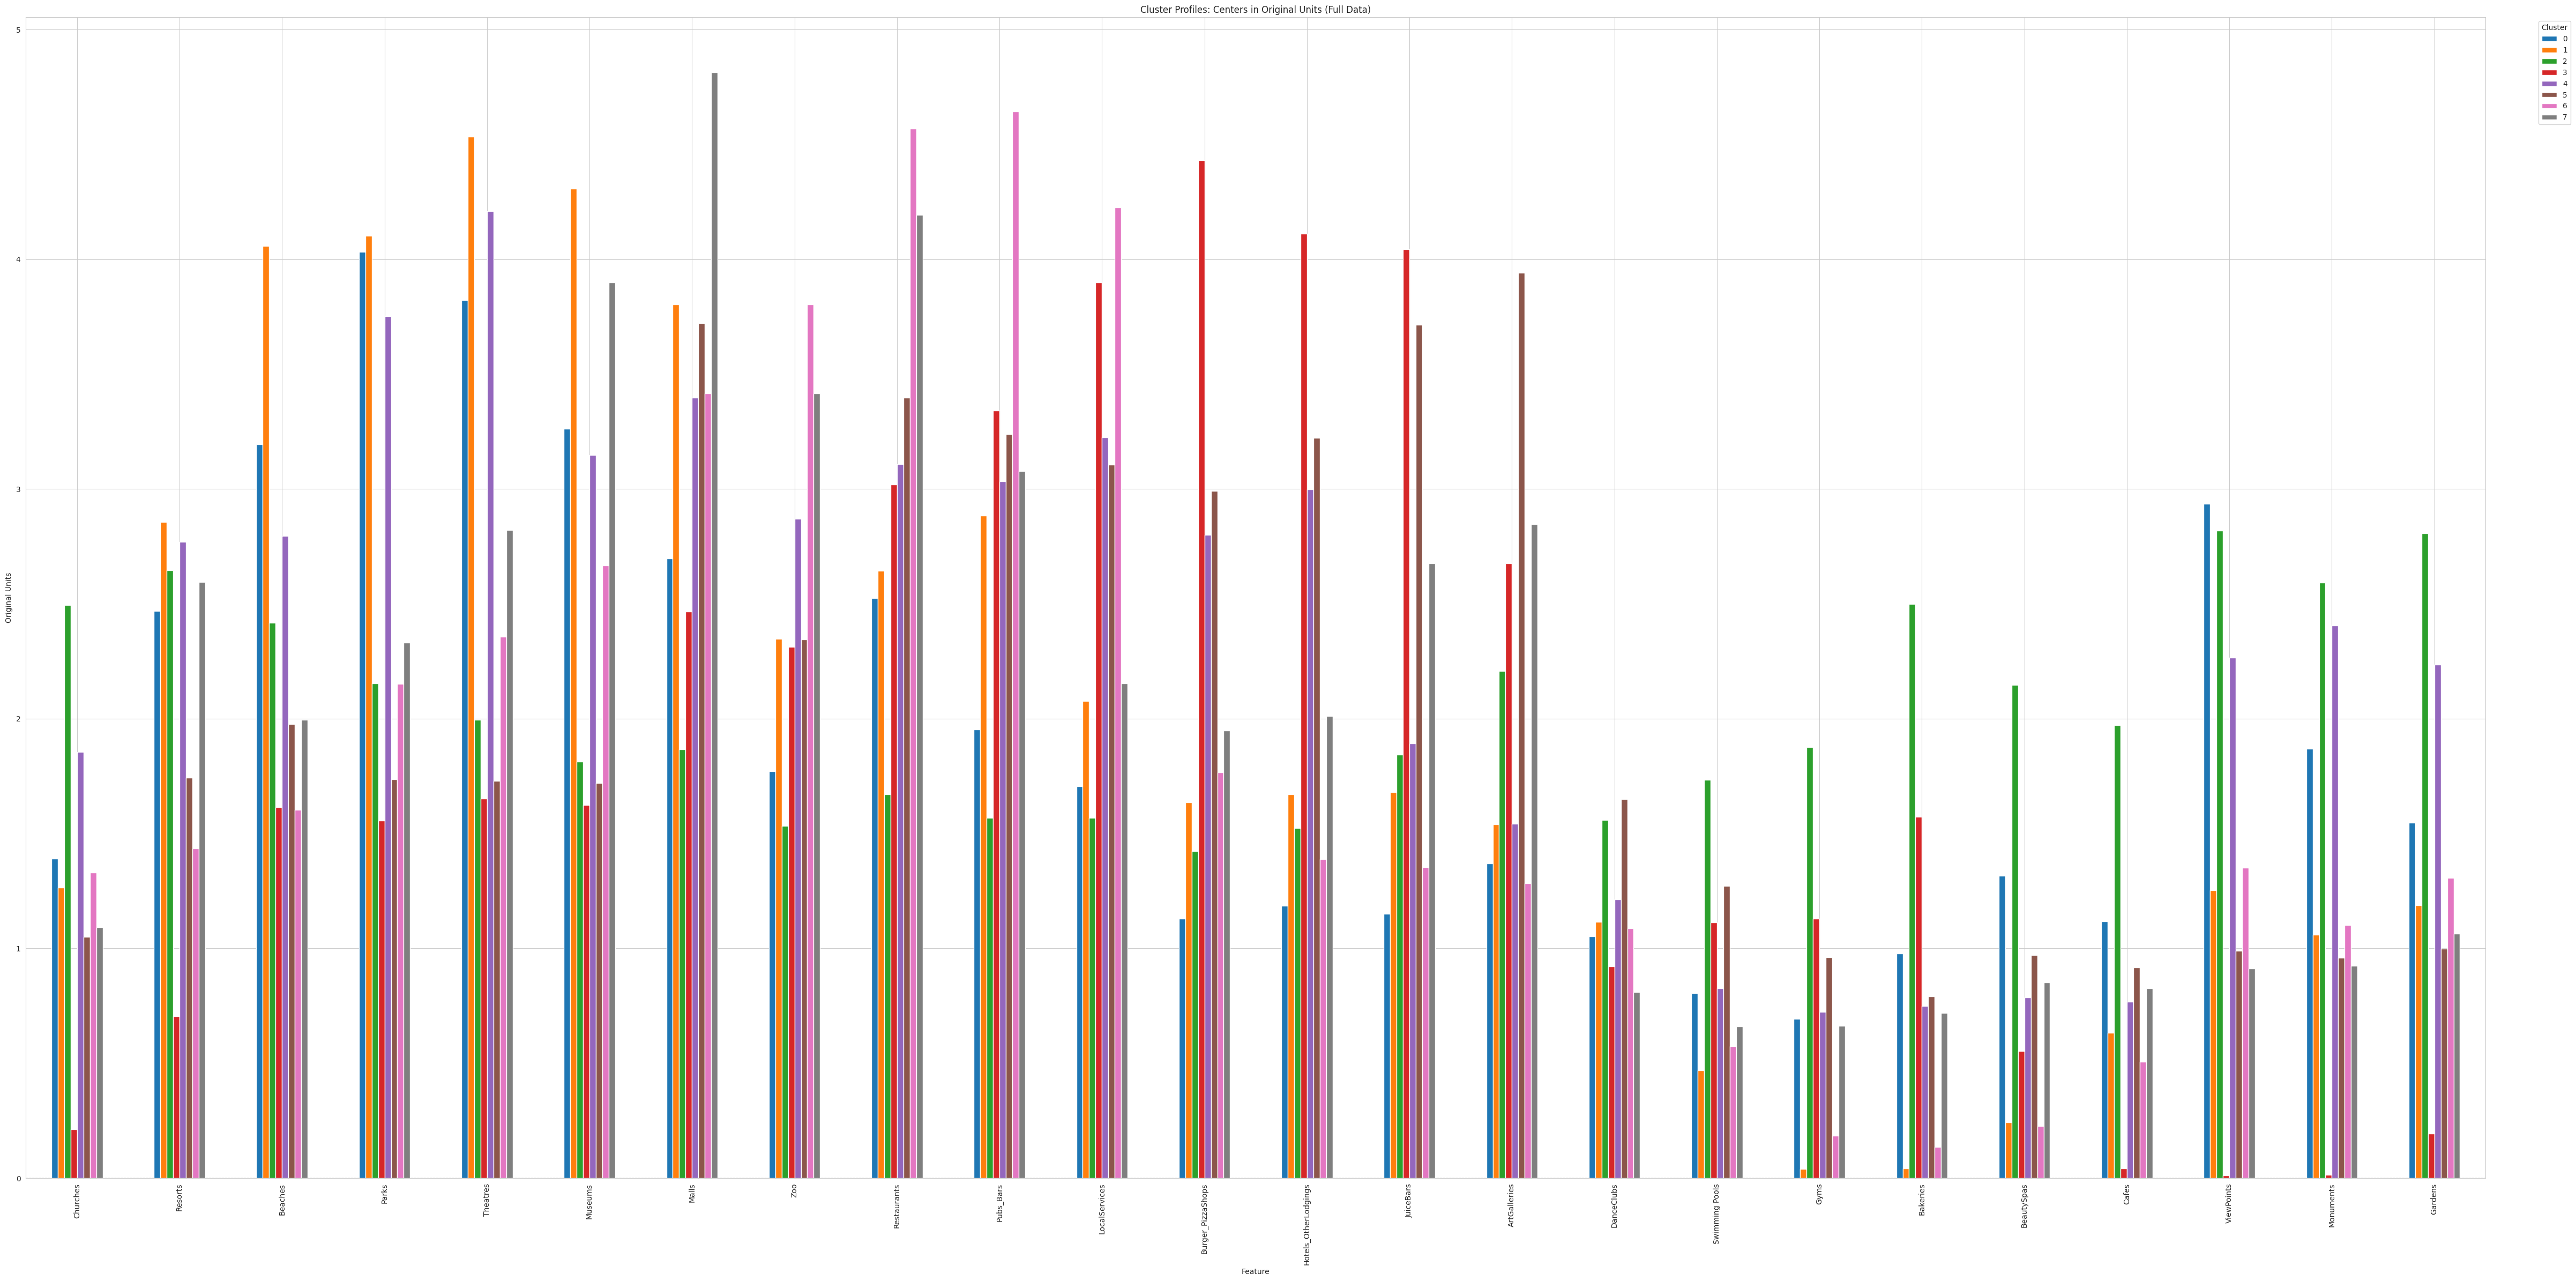

In [41]:
# Cluster profiles in original units
profile_orig = df_reviews.copy()
profile_orig["Cluster"] = cluster_labels

cluster_means_orig = profile_orig.groupby("Cluster")[reviews_cols].mean()
print("Cluster means in original units:")
display(cluster_means_orig.round(1))

cluster_means_orig.T.plot(kind="bar", figsize=(48, 24), edgecolor="white")
plt.title("Cluster Profiles: Centers in Original Units (Full Data)")
plt.ylabel("Original Units")
plt.xlabel("Feature")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

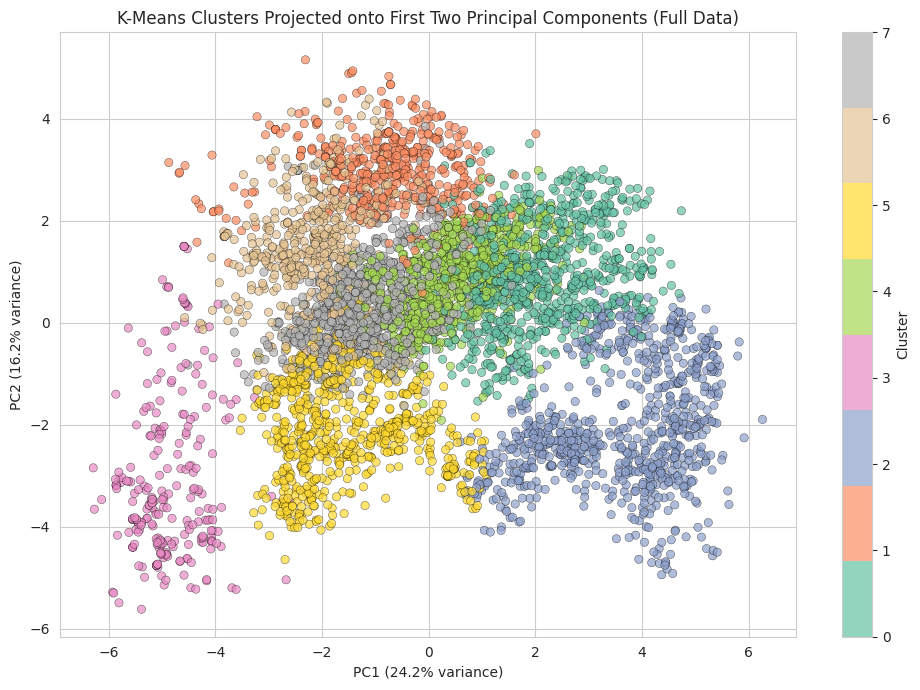

In [42]:
# PCA projection for visualization (full data)
pca_vis = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_vis = pca_vis.fit_transform(X_scaled_full)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=cluster_labels,
                      cmap="Set2", alpha=0.7, edgecolors="k", linewidth=0.3)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]:.1%} variance)")
plt.title("K-Means Clusters Projected onto First Two Principal Components (Full Data)")
plt.tight_layout()
plt.show()

Logistic Regression -- 5-fold CV Accuracy: 0.976 (+/- 0.010)


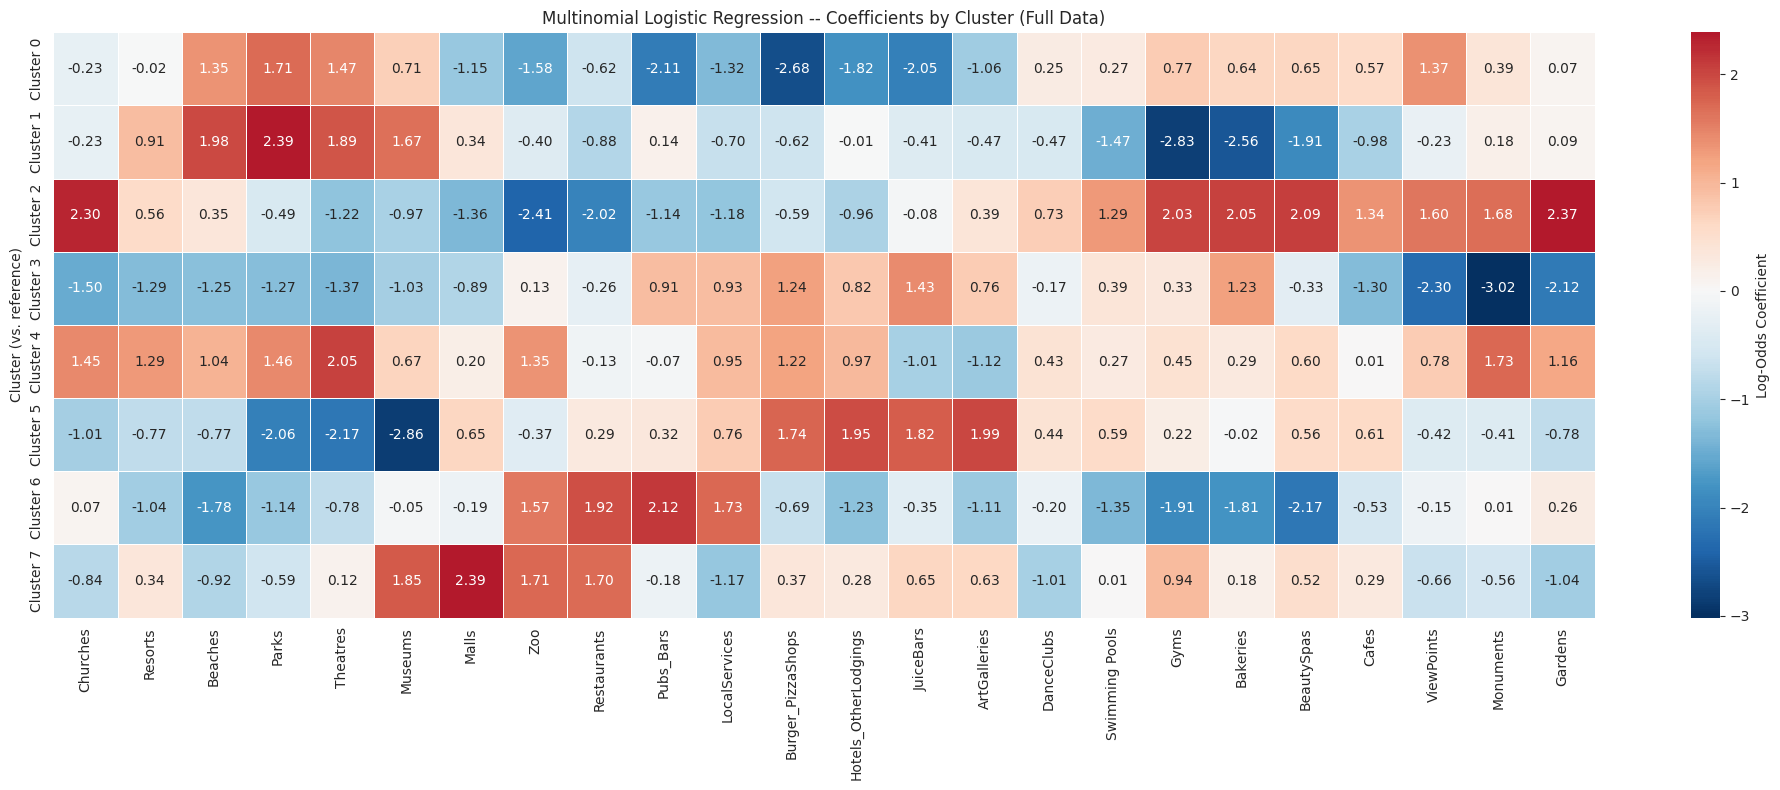

In [43]:
# ---------------------------------------------------
# Supervised Augmentation (on full data)
# Target = cluster_labels from KMeans on full data
# ---------------------------------------------------

# Multinomial Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_scaled_full, cluster_labels)

cv_scores_lr = cross_val_score(lr, X_scaled_full, cluster_labels, cv=5, scoring="accuracy")
print(f"Logistic Regression -- 5-fold CV Accuracy: {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std():.3f})")

coef_df = pd.DataFrame(lr.coef_, columns=reviews_cols,
                       index=[f"Cluster {i}" for i in range(k_chosen)])

plt.figure(figsize=(20, 8))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "Log-Odds Coefficient"})
plt.title("Multinomial Logistic Regression -- Coefficients by Cluster (Full Data)")
plt.ylabel("Cluster (vs. reference)")
plt.tight_layout()
plt.show()

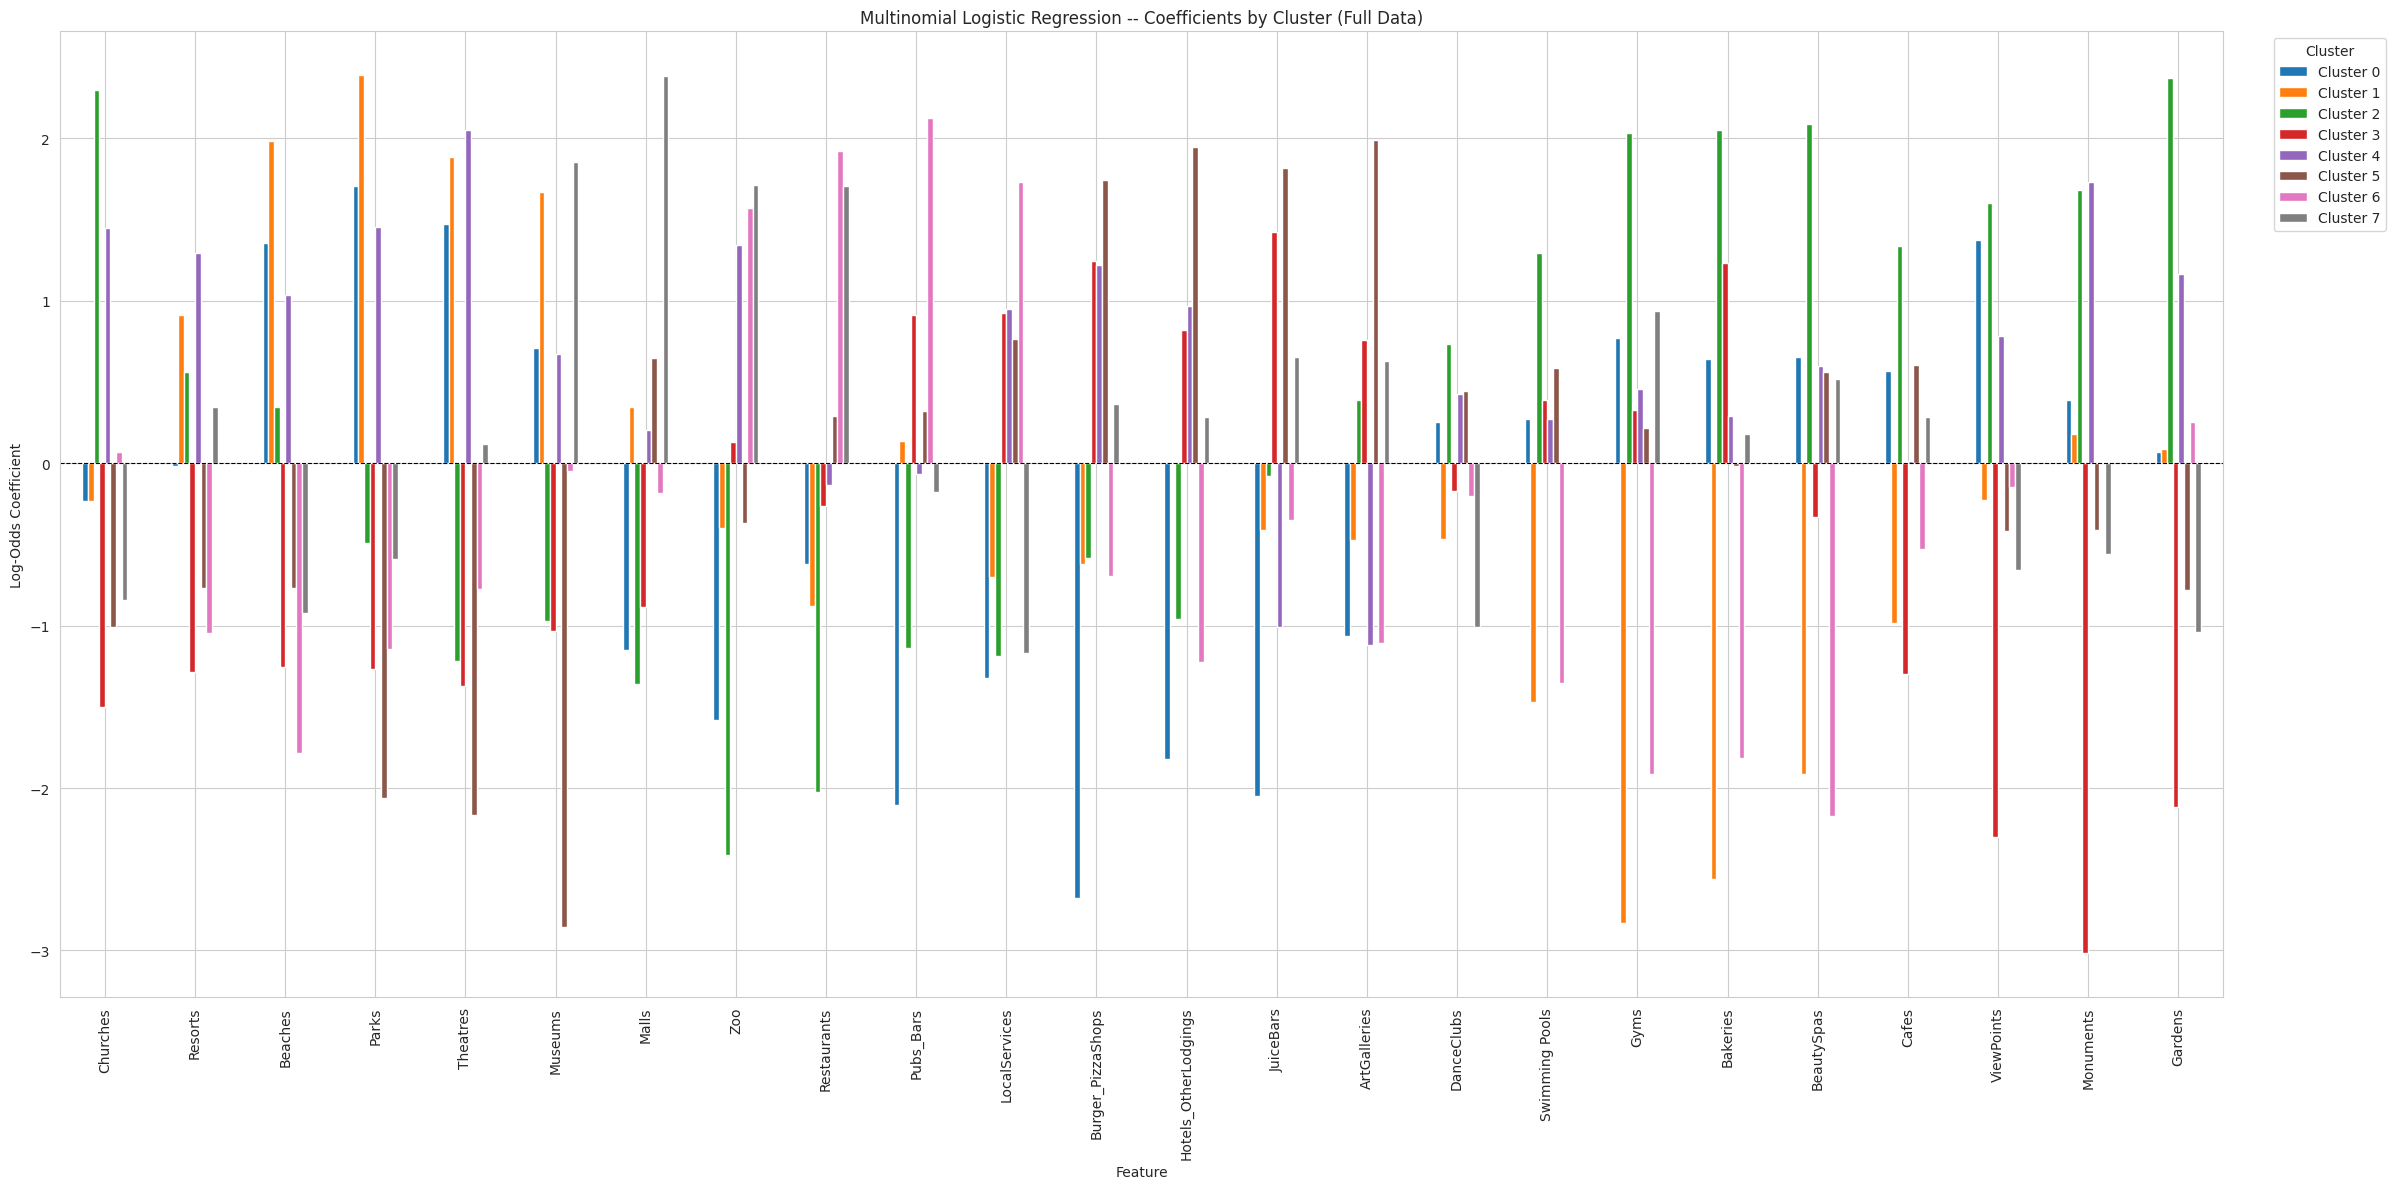

In [44]:
coef_df.T.plot(kind="bar", figsize=(24, 12), edgecolor="white")
plt.title("Multinomial Logistic Regression -- Coefficients by Cluster (Full Data)")
plt.ylabel("Log-Odds Coefficient")
plt.xlabel("Feature")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Decision Tree -- 5-fold CV Accuracy: 0.732 (+/- 0.066)


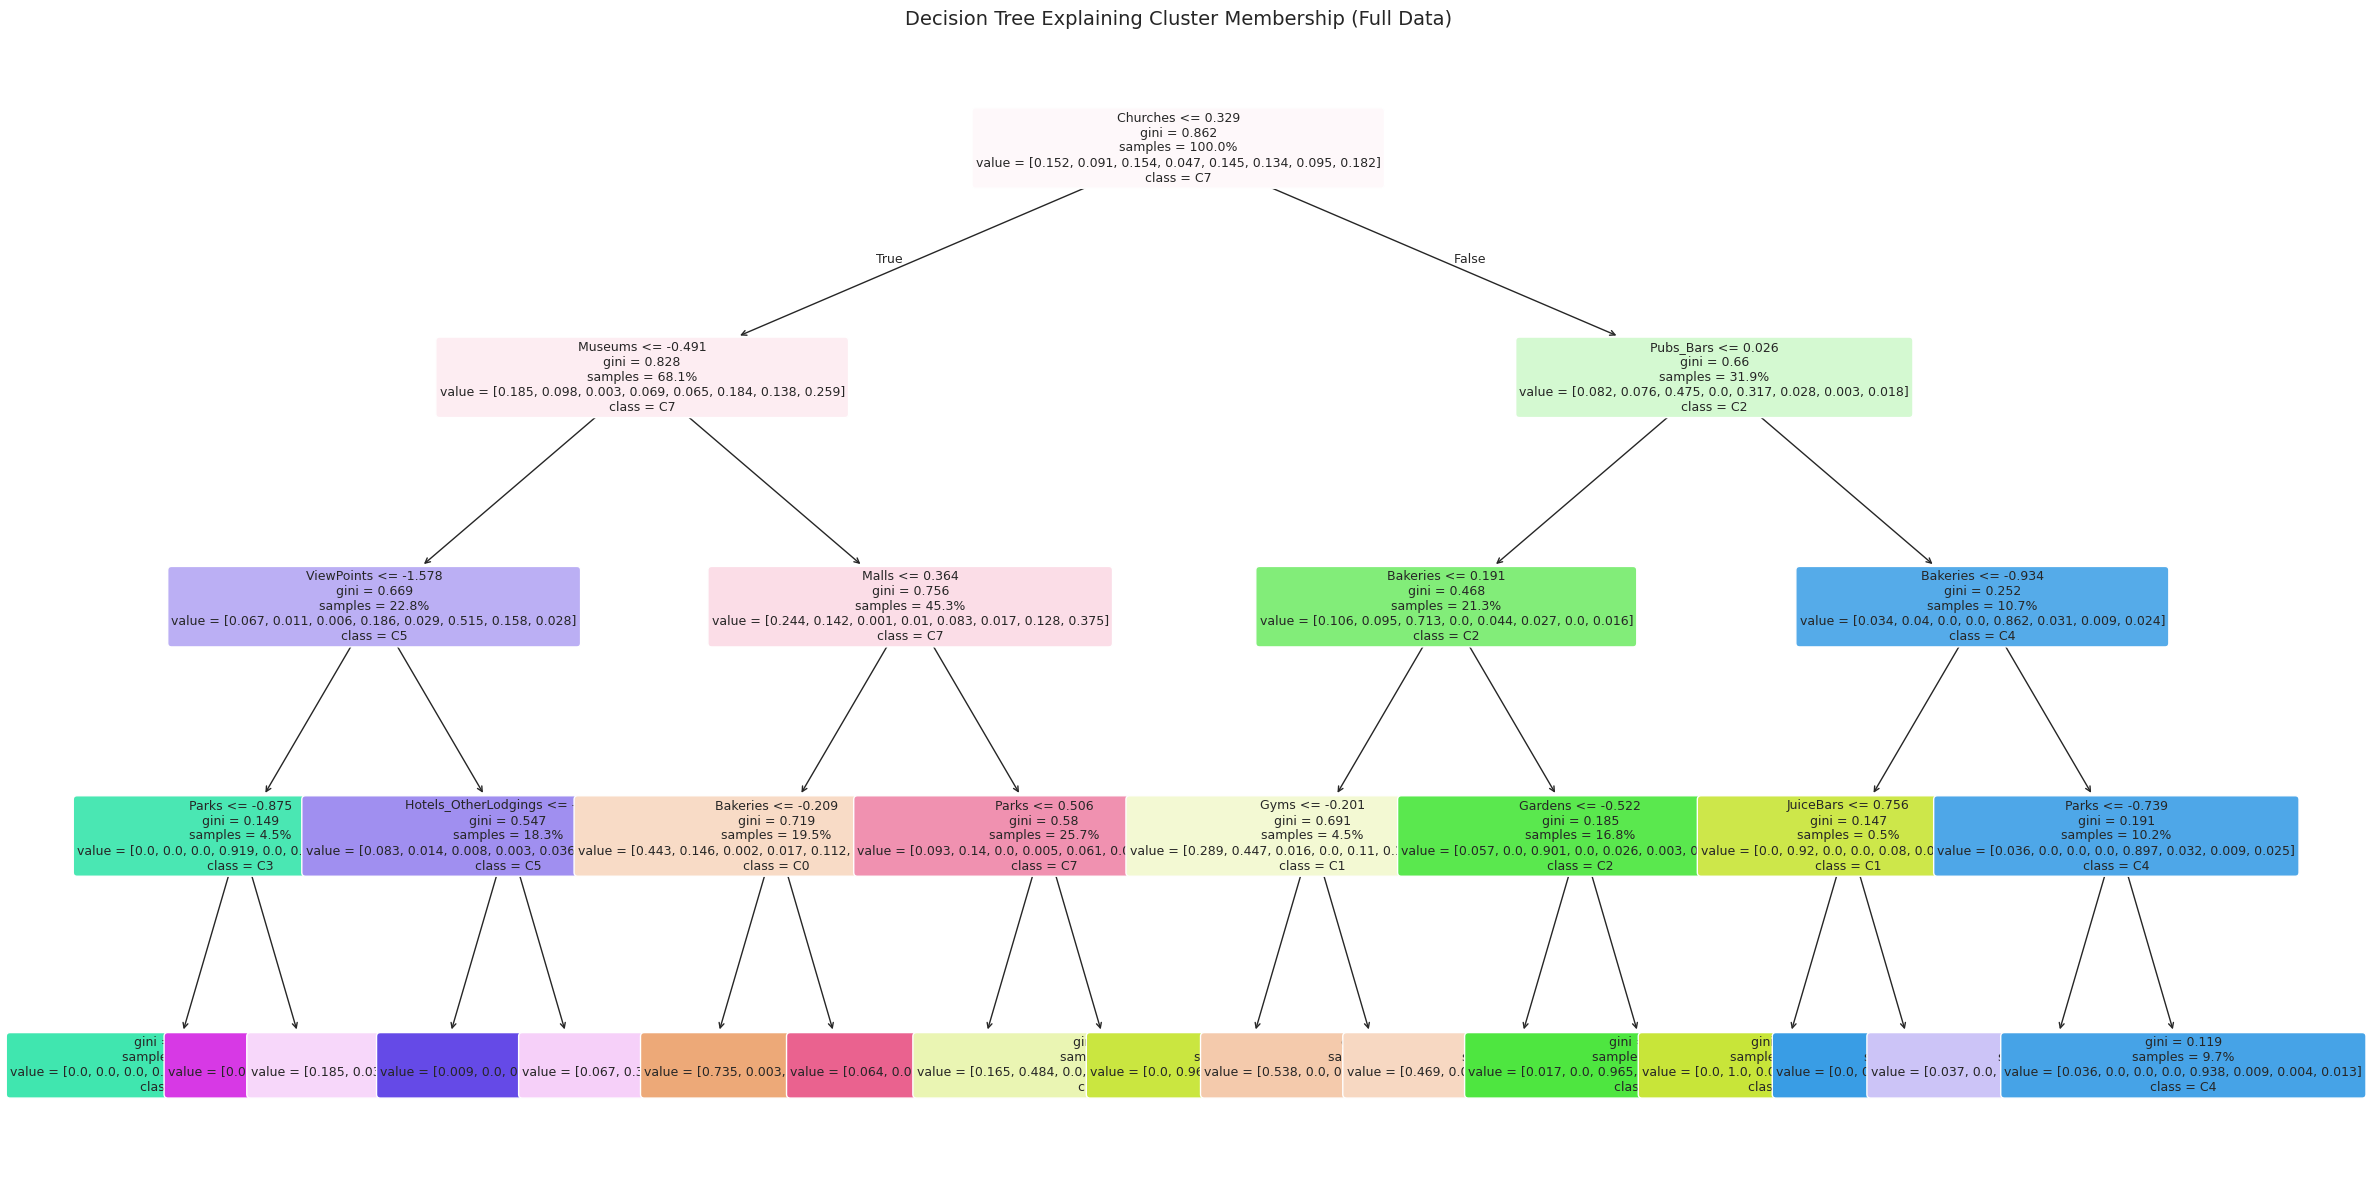

In [45]:
# Decision tree
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED)
dt.fit(X_scaled_full, cluster_labels)

cv_scores_dt = cross_val_score(dt, X_scaled_full, cluster_labels, cv=5, scoring="accuracy")
print(f"Decision Tree -- 5-fold CV Accuracy: {cv_scores_dt.mean():.3f} (+/- {cv_scores_dt.std():.3f})")

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt, feature_names=reviews_cols,
          class_names=[f"C{i}" for i in range(k_chosen)],
          filled=True, rounded=True, fontsize=9, ax=ax,
          proportion=True)
plt.title("Decision Tree Explaining Cluster Membership (Full Data)", fontsize=14)
plt.tight_layout()
plt.show()

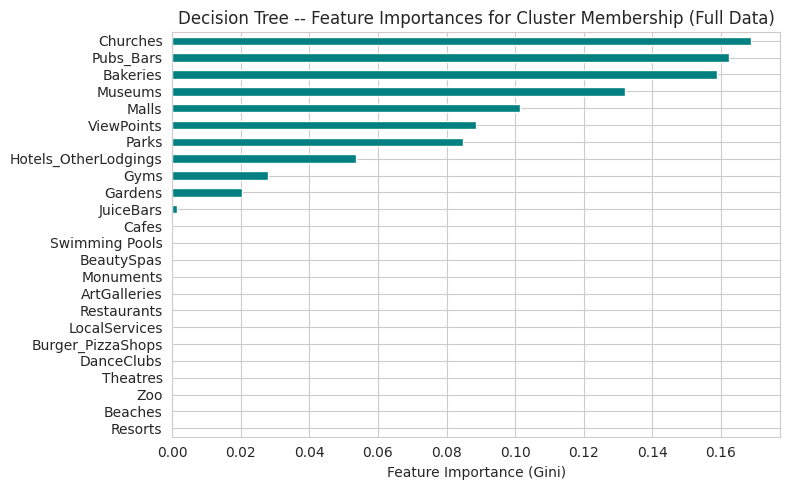

In [46]:
importances = pd.Series(dt.feature_importances_, index=reviews_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="teal", edgecolor="white")
plt.xlabel("Feature Importance (Gini)")
plt.title("Decision Tree -- Feature Importances for Cluster Membership (Full Data)")
plt.tight_layout()
plt.show()


## Additional Analysis
---
---

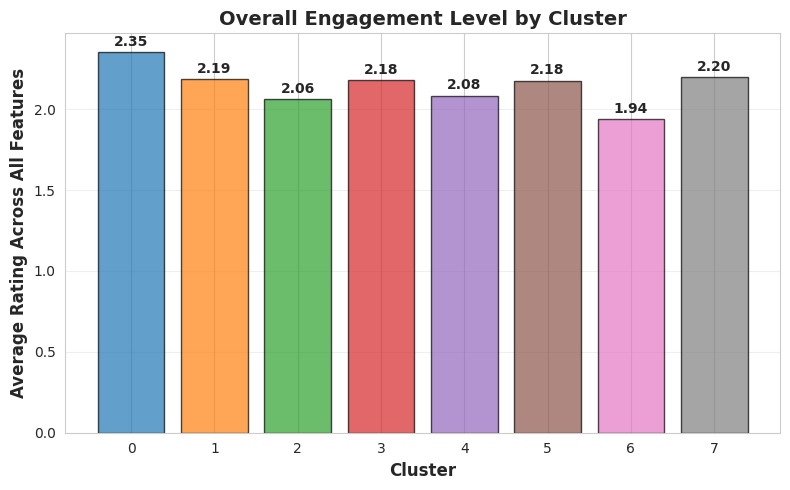

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the cluster-level averages (from the t-SNE cluster table) ---
cluster_data = {
    'cluster': [0, 1, 2, 3, 4, 5, 6, 7],
    'Churches': [1.10, 0.99, 2.05, 1.09, 1.27, 1.29, 2.39, 1.48],
    'Resorts': [1.40, 3.70, 2.90, 1.31, 1.41, 3.21, 2.54, 2.13],
    'Beaches': [1.89, 2.05, 3.37, 2.15, 1.65, 4.08, 2.33, 2.32],
    'Parks': [2.23, 2.14, 3.54, 2.09, 2.07, 4.32, 2.11, 3.55],
    'Theatres': [2.23, 2.56, 3.21, 2.31, 2.22, 4.42, 1.96, 4.26],
    'Museums': [1.99, 3.53, 2.65, 3.38, 2.32, 3.69, 1.77, 3.76],
    'Malls': [2.97, 4.68, 2.53, 4.59, 3.45, 3.14, 1.91, 3.88],
    'Zoo': [2.34, 2.75, 1.88, 3.99, 3.36, 2.29, 1.59, 2.61],
    'Restaurants': [3.18, 4.33, 2.70, 4.84, 4.07, 2.61, 1.69, 2.58],
    'Pubs_Bars': [3.15, 2.16, 2.12, 4.10, 4.14, 2.77, 1.62, 2.53],
    'LocalServices': [3.74, 1.89, 1.64, 2.13, 4.45, 2.30, 1.61, 2.58],
    'Burger_PizzaShops': [3.32, 1.86, 1.20, 1.61, 2.22, 1.56, 1.46, 2.87],
    'Hotels_OtherLodgings': [4.57, 2.57, 1.35, 1.70, 1.90, 1.54, 1.56, 2.26],
    'JuiceBars': [3.74, 2.86, 1.46, 2.32, 2.13, 1.53, 1.94, 1.83],
    'ArtGalleries': [2.95, 0.68, 1.78, 2.86, 2.19, 1.64, 2.28, 1.44],
    'DanceClubs': [1.15, 0.65, 1.18, 0.66, 1.18, 1.38, 1.81, 1.01],
    'Swimming_Pools': [0.77, 0.65, 0.88, 0.55, 0.63, 0.63, 2.04, 0.79],
    'Gyms': [1.02, 0.72, 0.80, 0.49, 0.32, 0.33, 2.17, 0.71],
    'Bakeries': [0.94, 0.76, 1.55, 0.58, 0.34, 0.32, 2.30, 0.72],
    'BeautySpas': [np.nan, np.nan, 2.43, 0.83, 0.35, 0.50, 1.71, 0.70]
}

df = pd.DataFrame(cluster_data)

# --- 2. Compute "overall engagement" = mean rating across all attributes for each cluster ---
feature_cols = [
    'Churches', 'Resorts', 'Beaches', 'Parks', 'Theatres', 'Museums',
    'Malls', 'Zoo', 'Restaurants', 'Pubs_Bars', 'LocalServices',
    'Burger_PizzaShops', 'Hotels_OtherLodgings', 'JuiceBars',
    'ArtGalleries', 'DanceClubs', 'Swimming_Pools', 'Gyms',
    'Bakeries', 'BeautySpas'
]

cluster_means = df[feature_cols].mean(axis=1)  # This is the engagement level per cluster

# --- 3. Plot the Overall Engagement Level by Cluster ---
plt.figure(figsize=(8, 5))
colors = plt.cm.tab10(range(len(df)))

bars = plt.bar(df['cluster'], cluster_means, color=colors, alpha=0.7, edgecolor='black')

plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Average Rating Across All Features', fontsize=12, fontweight='bold')
plt.title('Overall Engagement Level by Cluster', fontsize=14, fontweight='bold')
plt.xticks(df['cluster'])
plt.grid(axis='y', alpha=0.3)

# Add data labels
for bar, val in zip(bars, cluster_means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [48]:
cluster_pop = profile_scaled.groupby("Cluster")['Churches'].count()

In [49]:
print(cluster_pop)
(cluster_pop / 5455) * 100

Cluster
0    829
1    498
2    838
3    256
4    793
5    733
6    516
7    992
Name: Churches, dtype: int64


,Churches
Cluster,
0,15.197067
1,9.129239
2,15.362053
3,4.692942
4,14.537122
5,13.437214
6,9.459212
7,18.185151
